# Chapter 39: Camera Modeling and Calibration

This notebook is a compact executable companion to MIT Vision Book Chapter 39.
It keeps the chapter's original structure, displays every official MIT figure from the
MIT Vision Book directly in the notebook, and adds a small number of deterministic
CPU-friendly visualizations to make the geometry concrete.


In [1]:
import io
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import colors as mcolors
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

SEED = 39
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "index.ipynb").exists():
    candidate = NOTEBOOK_DIR / "notebooks" / "CV" / "2026" / "spring" / "final" / "chapter-39-camera-modeling"
    if candidate.exists():
        NOTEBOOK_DIR = candidate.resolve()
    else:
        matches = list(NOTEBOOK_DIR.rglob("chapter-39-camera-modeling/index.ipynb"))
        assert matches, f"Could not resolve the chapter directory from {Path.cwd()}"
        NOTEBOOK_DIR = matches[0].parent.resolve()

CHAPTER_DIR = NOTEBOOK_DIR

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8fafc",
        "axes.edgecolor": "#334155",
        "axes.labelcolor": "#0f172a",
        "axes.titlecolor": "#0f172a",
        "xtick.color": "#334155",
        "ytick.color": "#334155",
        "font.size": 11,
        "axes.grid": False,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#cbd5e1",
        "grid.color": "#cbd5e1",
        "grid.alpha": 0.45,
    }
)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "gray": "#475569",
    "light": "#94a3b8",
}


def savefig(fig, filename: str) -> None:
    del filename
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=180, bbox_inches="tight")
    buffer.seek(0)
    display(IPyImage(data=buffer.getvalue()))
    plt.close(fig)


def homogenize(points: torch.Tensor) -> torch.Tensor:
    ones = torch.ones((points.shape[0], 1), dtype=points.dtype)
    return torch.cat([points, ones], dim=1)


def rotation_x(angle_deg: float) -> torch.Tensor:
    t = math.radians(angle_deg)
    c, s = math.cos(t), math.sin(t)
    return torch.tensor([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]], dtype=torch.float64)


def rotation_y(angle_deg: float) -> torch.Tensor:
    t = math.radians(angle_deg)
    c, s = math.cos(t), math.sin(t)
    return torch.tensor([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], dtype=torch.float64)


def make_intrinsics(fx: float, fy: float, cx: float, cy: float) -> torch.Tensor:
    return torch.tensor([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=torch.float64)


def project_points(points_world: torch.Tensor, K: torch.Tensor, R: torch.Tensor, T: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    points_cam = (R @ (points_world - T).T).T
    pixels_h = (K @ points_cam.T).T
    pixels = pixels_h[:, :2] / pixels_h[:, 2:].clamp_min(1e-9)
    return pixels, points_cam


def build_dlt_matrix(points_world: torch.Tensor, pixels: torch.Tensor) -> torch.Tensor:
    rows = []
    for P, p in zip(points_world, pixels, strict=True):
        X, Y, Z = [float(v) for v in P]
        x, y = [float(v) for v in p]
        rows.append([-X, -Y, -Z, -1.0, 0.0, 0.0, 0.0, 0.0, x * X, x * Y, x * Z, x])
        rows.append([0.0, 0.0, 0.0, 0.0, -X, -Y, -Z, -1.0, y * X, y * Y, y * Z, y])
    return torch.tensor(rows, dtype=torch.float64)


def estimate_projection_matrix_dlt(points_world: torch.Tensor, pixels: torch.Tensor) -> torch.Tensor:
    A = build_dlt_matrix(points_world, pixels)
    _, _, vh = torch.linalg.svd(A)
    M = vh[-1].reshape(3, 4)
    return M / torch.linalg.norm(M)


def project_with_matrix(points_world: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    Xh = homogenize(points_world).T
    ph = (M @ Xh).T
    return ph[:, :2] / ph[:, 2:3].clamp_min(1e-9)


def light_grid(ax):
    ax.grid(True, linewidth=0.7, color="#cbd5e1", alpha=0.45)

from IPython.display import HTML, Image as IPyImage, display


def normalize_points_2d(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centroid = points.mean(axis=0)
    mean_distance = np.linalg.norm(points - centroid, axis=1).mean()
    scale = math.sqrt(2.0) / max(mean_distance, 1e-9)
    T = np.array(
        [
            [scale, 0.0, -scale * centroid[0]],
            [0.0, scale, -scale * centroid[1]],
            [0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    normalized = (T @ points_h.T).T
    return normalized[:, :2], T


def normalize_points_3d(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centroid = points.mean(axis=0)
    mean_distance = np.linalg.norm(points - centroid, axis=1).mean()
    scale = math.sqrt(3.0) / max(mean_distance, 1e-9)
    U = np.array(
        [
            [scale, 0.0, 0.0, -scale * centroid[0]],
            [0.0, scale, 0.0, -scale * centroid[1]],
            [0.0, 0.0, scale, -scale * centroid[2]],
            [0.0, 0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    normalized = (U @ points_h.T).T
    return normalized[:, :3], U


def build_dlt_matrix_numpy(points_world: np.ndarray, pixels: np.ndarray) -> np.ndarray:
    rows = []
    for point_world, pixel in zip(points_world, pixels, strict=True):
        X, Y, Z = point_world
        u, v = pixel
        rows.append([0.0, 0.0, 0.0, 0.0, -X, -Y, -Z, -1.0, v * X, v * Y, v * Z, v])
        rows.append([X, Y, Z, 1.0, 0.0, 0.0, 0.0, 0.0, -u * X, -u * Y, -u * Z, -u])
    return np.asarray(rows, dtype=np.float64)


def estimate_projection_matrix_normalized_dlt(points_world: np.ndarray, pixels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    normalized_pixels, T = normalize_points_2d(pixels)
    normalized_world, U = normalize_points_3d(points_world)
    A = build_dlt_matrix_numpy(normalized_world, normalized_pixels)
    _, _, vh = np.linalg.svd(A)
    projection_normalized = vh[-1].reshape(3, 4)
    projection = np.linalg.inv(T) @ projection_normalized @ U
    projection = projection / np.linalg.norm(projection[2, :3])
    if projection[2, 3] > 0.0:
        projection = -projection
    return projection, A


def project_with_projection_matrix(points_world: np.ndarray, projection: np.ndarray) -> np.ndarray:
    points_h = np.concatenate([points_world, np.ones((points_world.shape[0], 1), dtype=np.float64)], axis=1)
    projected_h = (projection @ points_h.T).T
    return projected_h[:, :2] / projected_h[:, 2:3]


def rq_decomposition(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    q_matrix, r_matrix = np.linalg.qr(np.flipud(matrix).T)
    r_matrix = np.flipud(r_matrix.T)
    r_matrix = np.fliplr(r_matrix)
    q_matrix = q_matrix.T
    q_matrix = np.flipud(q_matrix)
    diagonal_signs = np.where(np.diag(r_matrix) >= 0.0, 1.0, -1.0)
    sign_matrix = np.diag(diagonal_signs)
    r_matrix = r_matrix @ sign_matrix
    q_matrix = sign_matrix @ q_matrix
    if np.linalg.det(q_matrix) < 0.0:
        sign_matrix = np.diag([1.0, 1.0, -1.0])
        r_matrix = r_matrix @ sign_matrix
        q_matrix = sign_matrix @ q_matrix
    return r_matrix, q_matrix


def decompose_projection_matrix(projection: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    camera_matrix = projection[:, :3]
    intrinsics, rotation = rq_decomposition(camera_matrix)
    sign_matrix = np.diag(
        [
            -1.0 if intrinsics[0, 0] < 0.0 else 1.0,
            -1.0 if intrinsics[1, 1] < 0.0 else 1.0,
            1.0,
        ]
    )
    intrinsics = intrinsics @ sign_matrix
    rotation = sign_matrix @ rotation
    intrinsics = intrinsics / intrinsics[2, 2]
    translation = np.linalg.solve(intrinsics, projection[:, 3])
    camera_center = -np.linalg.inv(camera_matrix) @ projection[:, 3]
    return intrinsics, rotation, translation, camera_center


def render_html_table(rows: list[dict[str, object]], headers: list[str]) -> None:
    def fmt(value: object) -> str:
        if isinstance(value, float):
            return f"{value:.2f}"
        return str(value)

    header_html = ''.join(
        f'<th style="border:1px solid #cbd5e1;padding:6px 8px;background:#e2e8f0;text-align:left;">{header}</th>'
        for header in headers
    )
    body_html = []
    for row in rows:
        cells = ''.join(
            f'<td style="border:1px solid #cbd5e1;padding:6px 8px;vertical-align:top;">{fmt(row[header])}</td>'
            for header in headers
        )
        body_html.append(f'<tr>{cells}</tr>')
    html = (
        '<table style="border-collapse:collapse;font-size:0.92rem;min-width:720px;">'
        f'<thead><tr>{header_html}</tr></thead>'
        f'<tbody>{"".join(body_html)}</tbody></table>'
    )
    display(HTML(html))


def set_axes_equal(ax) -> None:
    x_limits = np.array(ax.get_xlim3d(), dtype=np.float64)
    y_limits = np.array(ax.get_ylim3d(), dtype=np.float64)
    z_limits = np.array(ax.get_zlim3d(), dtype=np.float64)
    spans = np.array([x_limits[1] - x_limits[0], y_limits[1] - y_limits[0], z_limits[1] - z_limits[0]])
    centers = np.array([x_limits.mean(), y_limits.mean(), z_limits.mean()])
    radius = 0.5 * spans.max()
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


## 39.1 Introduction

Chapter 39 shifts from the simple pinhole stories of earlier chapters to a more useful
camera model: one that can describe where the camera sits in the world, how it is
oriented, and how 3D points become pixels.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/world_and_camera_coordinates.png" alt="MIT Vision Book Figure 39.1" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.1, Figure 39.1. This original textbook figure contrasts a camera-centered frame with a world-centered frame. It matters here because the whole chapter is about moving between those frames cleanly.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/the_picture.png" alt="MIT Vision Book Figure 39.2" style="width: 38%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.1, Figure 39.2. This original textbook figure shows the image whose geometry the chapter later models. It matters because calibration always connects a real picture back to a 3D scene.</em></p>
</div>

The chapter's core idea is that calibration is about estimating the transformation from
world coordinates to image coordinates. Intrinsic parameters describe the camera itself.
Extrinsic parameters describe the camera's position and pose relative to the scene.


## 39.2 3D Camera Projections in Homogeneous Coordinates

Perspective projection contains a division by depth, which makes the equations awkward in
ordinary Euclidean coordinates. Homogeneous coordinates let us express the same mapping as
a matrix multiplication followed by a normalization step.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/camera_centric.png" alt="MIT Vision Book Figure 39.3" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.2, Figure 39.3. This original textbook figure shows how a 3D point projects through a pinhole onto the image plane. It matters because homogeneous coordinates re-express this geometry in matrix form.</em></p>
</div>

The point to keep in mind is that a 3D location `P = [X, Y, Z]^T` projects to image
coordinates roughly proportional to `X/Z` and `Y/Z`. Nearby points look larger because
dividing by a smaller depth amplifies the image coordinates.

### 39.2.1 Parallel Projection

Parallel projection removes that depth-dependent division. It is a simpler model that is
sometimes useful for distant scenes or for deriving intuition, but it does not capture
the foreshortening that real pinhole cameras produce.


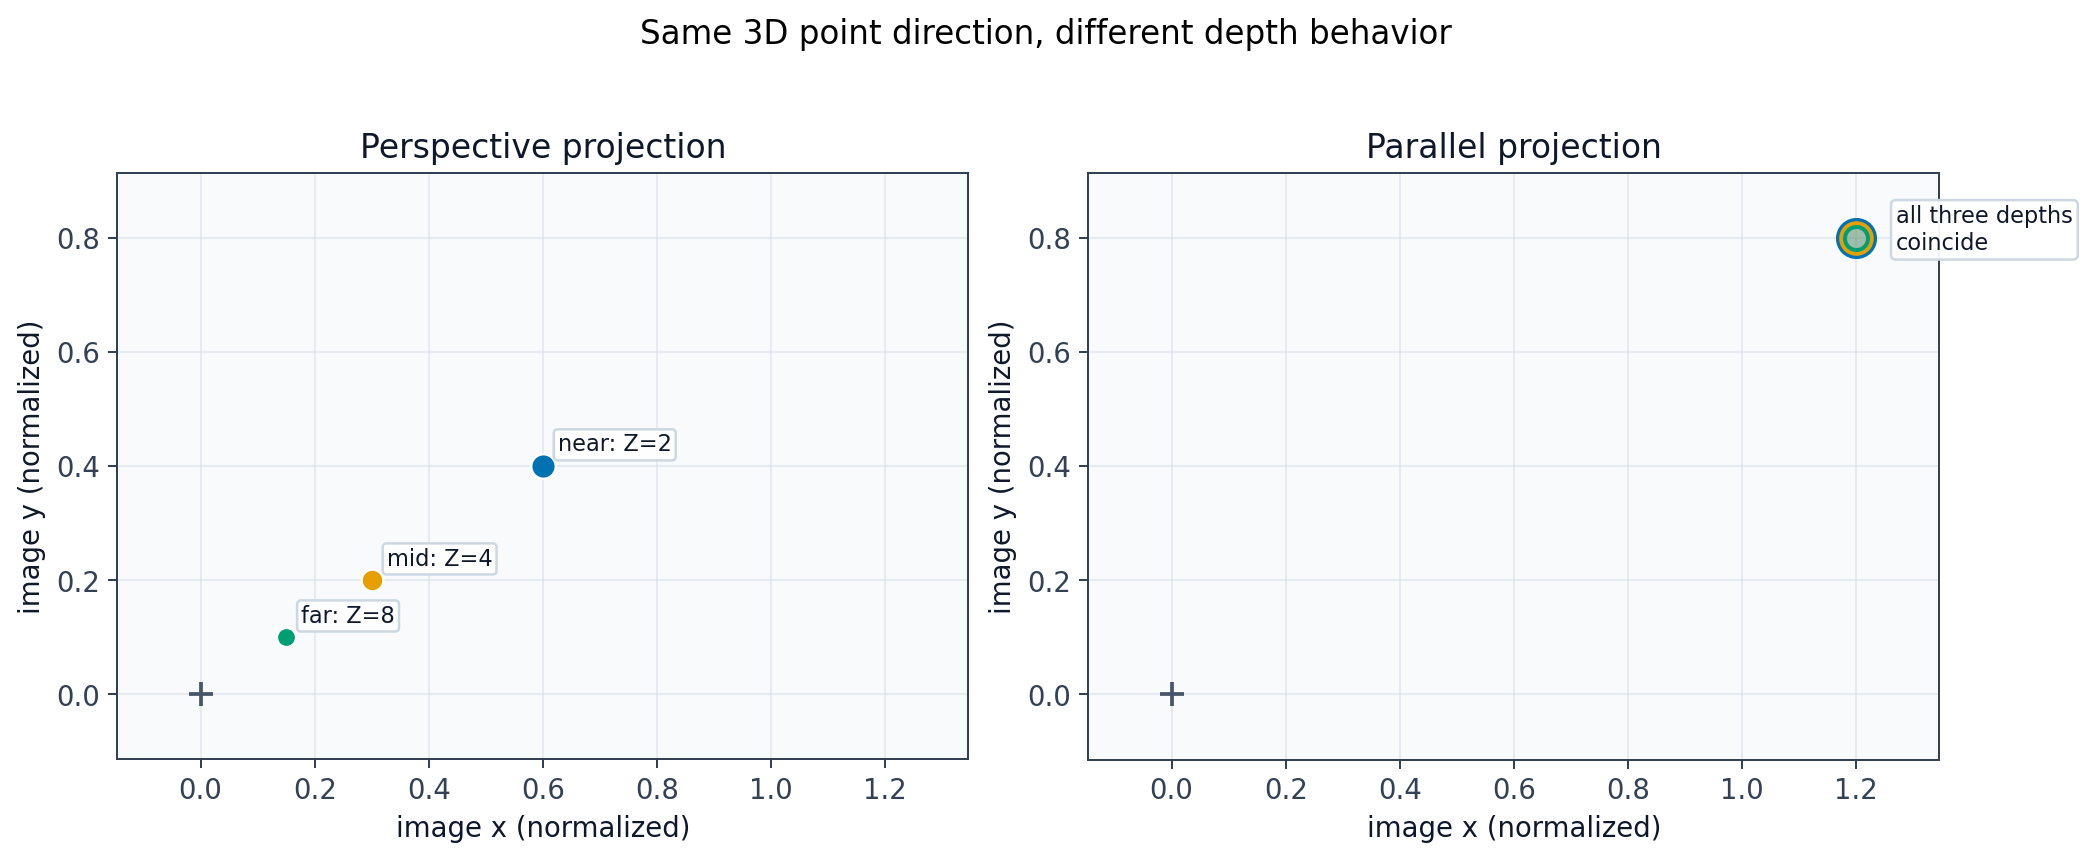

In [2]:
z_values = torch.tensor([2.0, 4.0, 8.0], dtype=torch.float64)
xy = torch.tensor([1.2, 0.8], dtype=torch.float64)
principal_point = torch.tensor([0.0, 0.0], dtype=torch.float64)
perspective_points = torch.stack([xy / z for z in z_values])
parallel_point = xy.clone()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)

labels = ["near", "mid", "far"]
colors = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
marker_sizes = [95, 75, 58]

persp_all = torch.vstack([perspective_points, principal_point.unsqueeze(0)])
parallel_all = torch.vstack([parallel_point.unsqueeze(0), principal_point.unsqueeze(0)])
all_points = torch.vstack([persp_all, parallel_all])
pad_x = 0.08 * float(all_points[:, 0].max() - all_points[:, 0].min()) + 0.05
pad_y = 0.08 * float(all_points[:, 1].max() - all_points[:, 1].min()) + 0.05
xlim = (float(all_points[:, 0].min()) - pad_x, float(all_points[:, 0].max()) + pad_x)
ylim = (float(all_points[:, 1].min()) - pad_y, float(all_points[:, 1].max()) + pad_y)

ax = axes[0]
for point, depth, label, color, size in zip(perspective_points, z_values, labels, colors, marker_sizes, strict=True):
    ax.scatter(float(point[0]), float(point[1]), s=size, color=color, edgecolor="white", linewidth=0.9, zorder=3)
    ax.annotate(
        f"{label}: Z={depth:.0f}",
        xy=(float(point[0]), float(point[1])),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="#cbd5e1", alpha=0.95),
    )
ax.scatter(float(principal_point[0]), float(principal_point[1]), marker="+", s=90, color=COLORS["gray"], linewidth=1.5, zorder=4)
ax.set_title("Perspective projection")
ax.set_xlabel("image x (normalized)")
ax.set_ylabel("image y (normalized)")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
light_grid(ax)

ax = axes[1]
for depth, color, size, alpha in zip(z_values, colors, [220, 150, 85], [0.32, 0.22, 0.12], strict=True):
    ax.scatter(
        float(parallel_point[0]),
        float(parallel_point[1]),
        s=size,
        facecolor=mcolors.to_rgba(color, alpha),
        edgecolor=color,
        linewidth=1.6,
        zorder=3,
        label=f"Z={depth:.0f}",
    )
ax.scatter(float(principal_point[0]), float(principal_point[1]), marker="+", s=90, color=COLORS["gray"], linewidth=1.5, zorder=4)
ax.text(
    float(parallel_point[0]) + 0.07,
    float(parallel_point[1]) - 0.02,
    "all three depths\ncoincide",
    fontsize=9,
    color="#0f172a",
    bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="#cbd5e1", alpha=0.95),
)
ax.set_title("Parallel projection")
ax.set_xlabel("image x (normalized)")
ax.set_ylabel("image y (normalized)")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
light_grid(ax)

fig.suptitle("Same 3D point direction, different depth behavior", fontsize=13)
savefig(fig, "01-projection-models.png")


**Supplemental visualization for MIT Vision Book Section 39.2.**

We projected the same lateral 3D point at three depths using both perspective and parallel projection. The perspective panel shrinks image coordinates with increasing depth, while the parallel panel keeps them fixed. That is the key geometric difference between Sections 39.2 and 39.2.1.


## 39.3 Camera-Intrinsic Parameters

Intrinsic parameters describe how the camera turns rays into pixels. In practice, this
includes focal scaling, the principal point, and sometimes unequal pixel scales, skew,
or lens distortion.

### 39.3.1 From Meters to Pixels

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/pinhole_and_sensor.png" alt="MIT Vision Book Figure 39.4" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.1, Figure 39.4. This original textbook figure shows how focal length, sensor width, and pixel sampling connect physical geometry to image coordinates. It matters because intrinsic calibration lives in that conversion.</em></p>
</div>

The intrinsic matrix tells us how to convert camera-plane coordinates into pixel
coordinates. The chapter uses `a` and `b` for horizontal and vertical focal scaling, and
`(c_x, c_y)` for the principal point.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/conventions_coordinates.png" alt="MIT Vision Book Figure 39.5" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.1, Figure 39.5. This original textbook figure compares common image-coordinate conventions. It matters because sign choices and origin placement change how we write the intrinsic matrix.</em></p>
</div>

In code, it is worth being explicit about conventions: image origins, axis directions,
and sign choices all affect the exact matrix form even when the geometry is the same.

### 39.3.2 From Pixels to Rays

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/light_ray.png" alt="MIT Vision Book Figure 39.6" style="width: 76%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.2, Figure 39.6. This original textbook figure shows that a single pixel defines a whole 3D ray, not a unique 3D point. It matters because depth is what turns that ray back into a specific scene location.</em></p>
</div>

Backprojection reverses the forward camera map only up to a ray. If a pixel is known and
the depth is unknown, there are infinitely many 3D points consistent with that pixel.

### 39.3.3 A Simple, although Unreliable, Calibration Method

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
<img src="https://visionbook.mit.edu/figures/imaging_geometry/simple_calibration_1.jpg" alt="MIT Vision Book Figure 39.7" style="width: 60%; max-width: 100%; height: auto;" />
<img src="https://visionbook.mit.edu/figures/imaging_geometry/simple_calibration_2.jpg" alt="MIT Vision Book Figure 39.7" style="width: 32%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.3, Figure 39.7. This original textbook figure groups the physical setup and the captured chessboard image. It matters because the chapter first introduces calibration as a measurement problem before presenting more general estimation methods.</em></p>
</div>

This sanity-check method uses a known target, a measured distance, and the apparent size
of the target in the image to estimate focal scaling. It is useful for intuition, but it
ignores many practical effects such as distortion and imperfect alignment.

### 39.3.4 Other Camera Parameters

Real cameras may also need skew terms, separate horizontal and vertical pixel scales, and
especially distortion correction. In practice, radial distortion is often the first extra
effect that visibly breaks the simplest pinhole model.


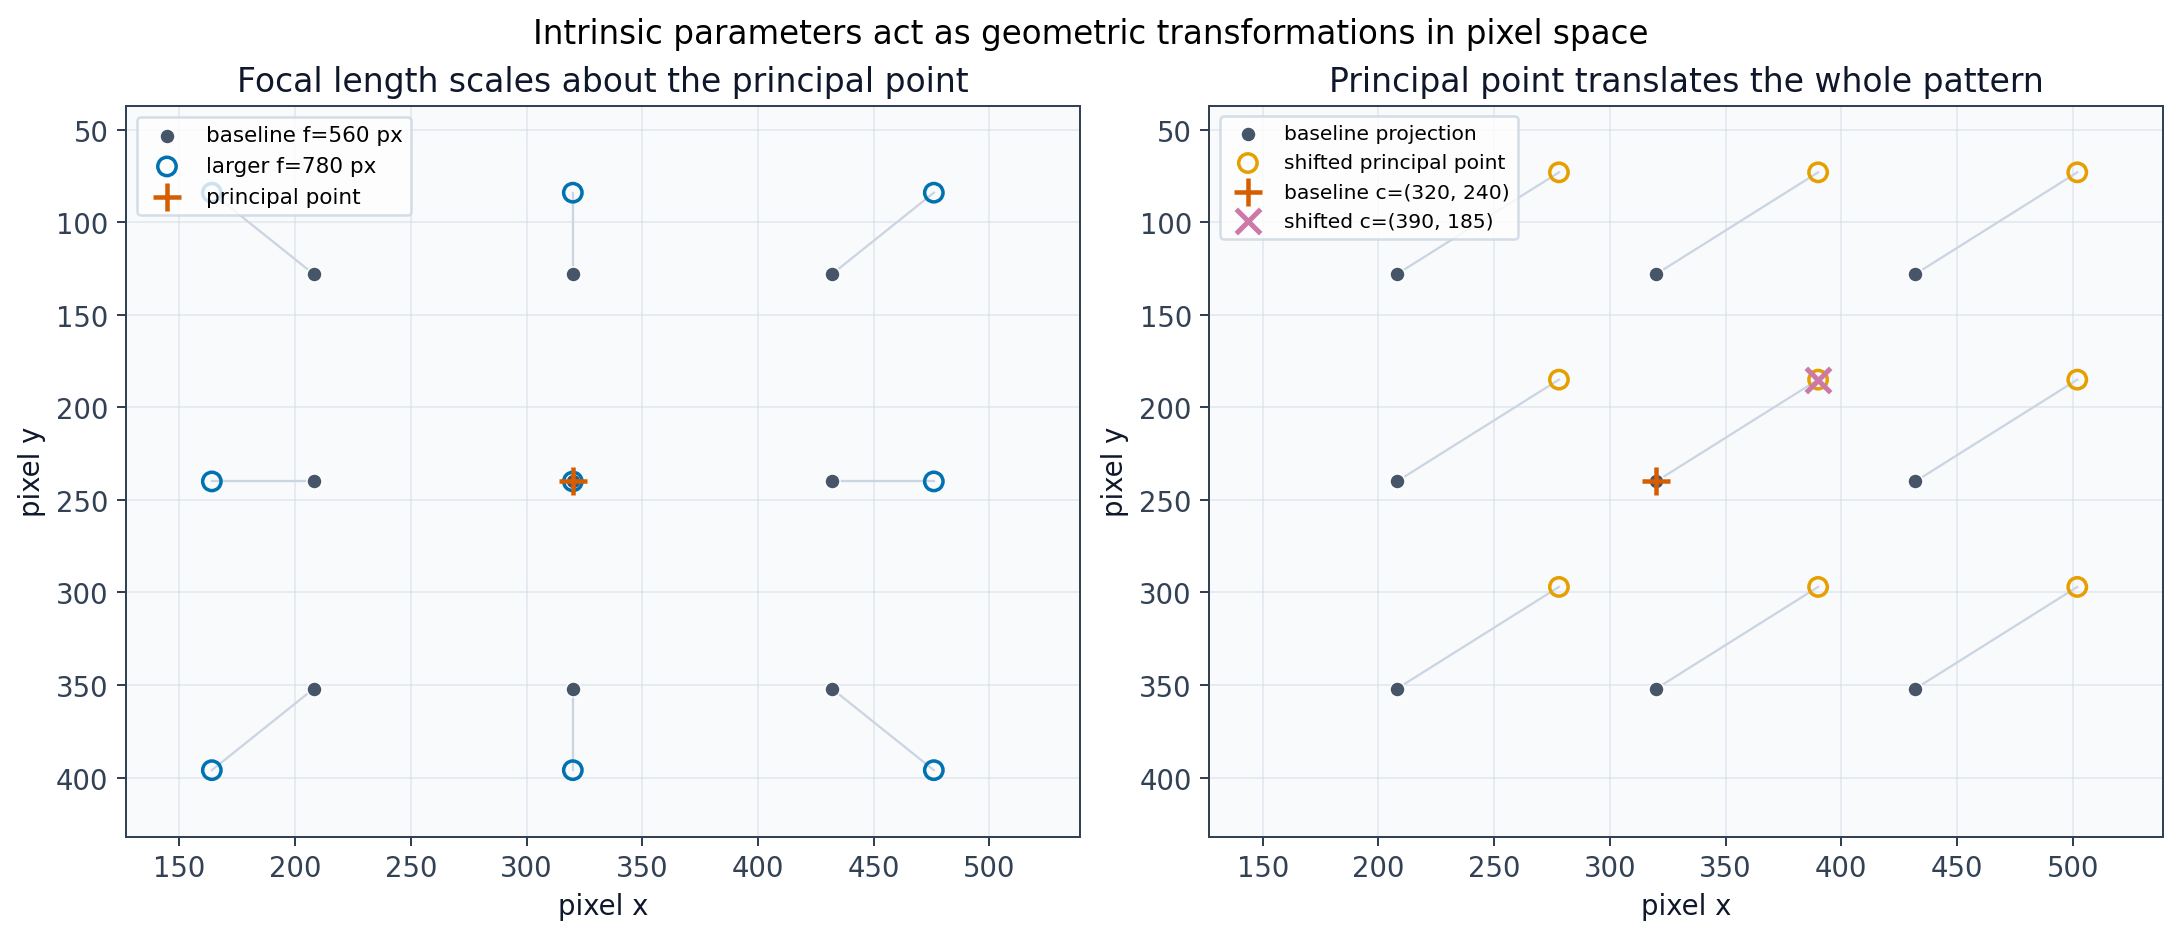

In [3]:
pattern_xy = torch.tensor(
    [
        [-0.9, -0.9], [0.0, -0.9], [0.9, -0.9],
        [-0.9,  0.0], [0.0,  0.0], [0.9,  0.0],
        [-0.9,  0.9], [0.0,  0.9], [0.9,  0.9],
    ],
    dtype=torch.float64,
)
pattern_depth = torch.full((pattern_xy.shape[0], 1), 4.5, dtype=torch.float64)
pattern_3d = torch.cat([pattern_xy, pattern_depth], dim=1)
K_base = make_intrinsics(560.0, 560.0, 320.0, 240.0)
K_focal = make_intrinsics(780.0, 780.0, 320.0, 240.0)
K_shift = make_intrinsics(560.0, 560.0, 390.0, 185.0)
R_eye = torch.eye(3, dtype=torch.float64)
T_zero = torch.zeros(3, dtype=torch.float64)

baseline_pixels, _ = project_points(pattern_3d, K_base, R_eye, T_zero)
focal_pixels, _ = project_points(pattern_3d, K_focal, R_eye, T_zero)
shift_pixels, _ = project_points(pattern_3d, K_shift, R_eye, T_zero)
principal_base = torch.tensor([320.0, 240.0], dtype=torch.float64)
principal_shift = torch.tensor([390.0, 185.0], dtype=torch.float64)

all_points = torch.vstack([baseline_pixels, focal_pixels, shift_pixels, principal_base.unsqueeze(0), principal_shift.unsqueeze(0)])
pad_x = 0.08 * float(all_points[:, 0].max() - all_points[:, 0].min()) + 10.0
pad_y = 0.08 * float(all_points[:, 1].max() - all_points[:, 1].min()) + 10.0
xlim = (float(all_points[:, 0].min()) - pad_x, float(all_points[:, 0].max()) + pad_x)
y_top = float(all_points[:, 1].min()) - pad_y
y_bottom = float(all_points[:, 1].max()) + pad_y

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.1), constrained_layout=True)

ax = axes[0]
for base_pt, changed_pt in zip(baseline_pixels, focal_pixels, strict=True):
    ax.plot([float(base_pt[0]), float(changed_pt[0])], [float(base_pt[1]), float(changed_pt[1])], color="#cbd5e1", lw=0.9, zorder=1)
ax.scatter(baseline_pixels[:, 0], baseline_pixels[:, 1], s=36, color=COLORS["gray"], edgecolor="white", linewidth=0.6, label="baseline f=560 px", zorder=3)
ax.scatter(focal_pixels[:, 0], focal_pixels[:, 1], s=54, facecolor="none", edgecolor=COLORS["blue"], linewidth=1.4, label="larger f=780 px", zorder=4)
ax.scatter([float(principal_base[0])], [float(principal_base[1])], marker="+", s=120, color=COLORS["vermillion"], linewidth=1.8, label="principal point", zorder=5)
ax.set_title("Focal length scales about the principal point")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_xlim(*xlim)
ax.set_ylim(y_bottom, y_top)
light_grid(ax)
ax.legend(loc="upper left", fontsize=8.6)

ax = axes[1]
for base_pt, changed_pt in zip(baseline_pixels, shift_pixels, strict=True):
    ax.plot([float(base_pt[0]), float(changed_pt[0])], [float(base_pt[1]), float(changed_pt[1])], color="#cbd5e1", lw=0.9, zorder=1)
ax.scatter(baseline_pixels[:, 0], baseline_pixels[:, 1], s=36, color=COLORS["gray"], edgecolor="white", linewidth=0.6, label="baseline projection", zorder=3)
ax.scatter(shift_pixels[:, 0], shift_pixels[:, 1], s=54, facecolor="none", edgecolor=COLORS["orange"], linewidth=1.4, label="shifted principal point", zorder=4)
ax.scatter([float(principal_base[0])], [float(principal_base[1])], marker="+", s=120, color=COLORS["vermillion"], linewidth=1.8, label="baseline c=(320, 240)", zorder=5)
ax.scatter([float(principal_shift[0])], [float(principal_shift[1])], marker="x", s=95, color=COLORS["purple"], linewidth=2.0, label="shifted c=(390, 185)", zorder=5)
ax.set_title("Principal point translates the whole pattern")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_xlim(*xlim)
ax.set_ylim(y_bottom, y_top)
light_grid(ax)
ax.legend(loc="upper left", fontsize=8.1)

fig.suptitle("Intrinsic parameters act as geometric transformations in pixel space", fontsize=13)
savefig(fig, "02-intrinsics-effects.png")


**Computational reconstruction related to MIT Vision Book Section 39.3, Figure 39.4.**

We projected the same nine 3D points while changing either focal scaling or the principal point. Larger focal length magnifies the image, while changing `(c_x, c_y)` translates all projected points together. Those are two of the central effects encoded by the intrinsic matrix.


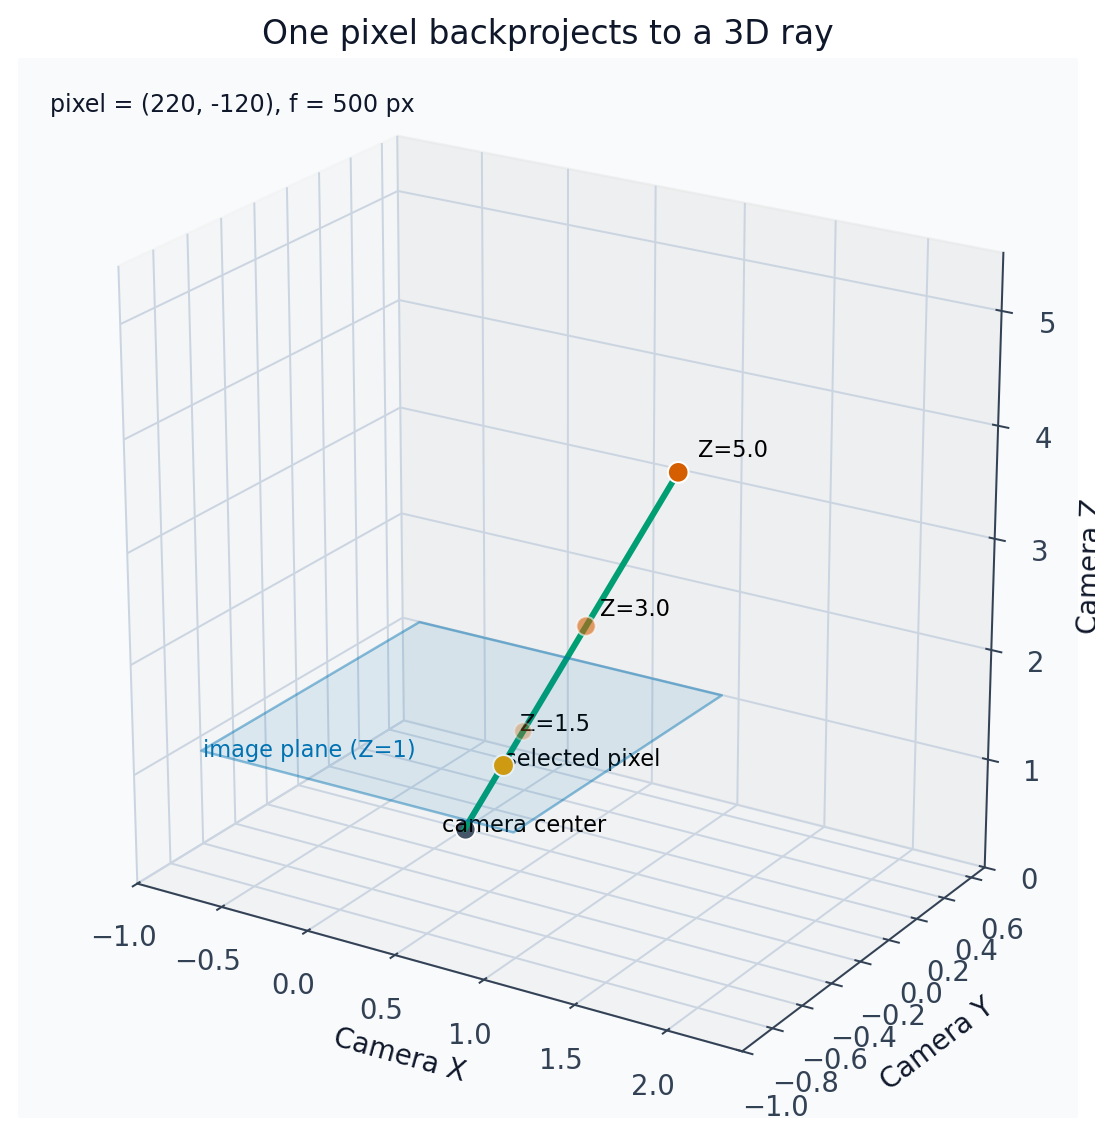

In [4]:
pixel = torch.tensor([220.0, -120.0], dtype=torch.float64)
focal = 500.0
depths = torch.tensor([1.5, 3.0, 5.0], dtype=torch.float64)
plane_depth = 1.0
pixel_on_plane = torch.tensor([pixel[0] / focal, pixel[1] / focal, plane_depth], dtype=torch.float64)
ray_dir = pixel_on_plane.clone()
ray_points = depths.unsqueeze(1) * ray_dir.unsqueeze(0)

plane_w, plane_h = 0.9, 0.7
plane_vertices = [
    [-plane_w, -plane_h, plane_depth],
    [ plane_w, -plane_h, plane_depth],
    [ plane_w,  plane_h, plane_depth],
    [-plane_w,  plane_h, plane_depth],
]

fig = plt.figure(figsize=(8.2, 6.2), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
a = Poly3DCollection([plane_vertices], facecolors=mcolors.to_rgba(COLORS["blue"], 0.10), edgecolors=mcolors.to_rgba(COLORS["blue"], 0.45), linewidths=1.0)
ax.add_collection3d(a)
ax.plot([0.0, float(ray_points[-1, 0])], [0.0, float(ray_points[-1, 1])], [0.0, float(ray_points[-1, 2])], color=COLORS["green"], lw=2.4, zorder=3)
ax.scatter([0.0], [0.0], [0.0], color=COLORS["gray"], s=64, edgecolor="white", linewidth=0.7, zorder=5)
ax.scatter([float(pixel_on_plane[0])], [float(pixel_on_plane[1])], [plane_depth], color=COLORS["orange"], s=70, edgecolor="white", linewidth=0.8, zorder=6)
ax.scatter(ray_points[:, 0], ray_points[:, 1], ray_points[:, 2], color=COLORS["vermillion"], s=[48, 58, 68], edgecolor="white", linewidth=0.8, zorder=7)

label_offsets = [(0.05, -0.08, 0.10), (0.06, 0.02, 0.10), (0.05, 0.06, 0.10)]
for point, depth, (dx, dy, dz) in zip(ray_points, depths, label_offsets, strict=True):
    ax.text(float(point[0] + dx), float(point[1] + dy), float(point[2] + dz), f"Z={depth:.1f}", fontsize=9)

ax.text2D(0.03, 0.95, "pixel = (220, -120), f = 500 px", transform=ax.transAxes, fontsize=9.5, color="#0f172a")
ax.text(float(pixel_on_plane[0] + 0.04), float(pixel_on_plane[1] - 0.03), float(pixel_on_plane[2] + 0.04), "selected pixel", fontsize=9)
ax.text(-0.08, -0.06, 0.0, "camera center", fontsize=9)
ax.text(-0.83, -0.76, plane_depth + 0.03, "image plane (Z=1)", fontsize=9, color=COLORS["blue"])
ax.set_title("One pixel backprojects to a 3D ray")
ax.set_xlabel("Camera X")
ax.set_ylabel("Camera Y")
ax.set_zlabel("Camera Z")
ax.set_xlim(-1.0, 2.4)
ax.set_ylim(-1.0, 0.7)
ax.set_zlim(0.0, 5.5)
ax.set_box_aspect((1.45, 1.0, 1.35))
ax.view_init(elev=22, azim=-58)
savefig(fig, "03-pixel-to-ray-backprojection.png")


**Computational reconstruction related to MIT Vision Book Section 39.3.2, Figure 39.6.**

We chose one pixel direction and sampled three depths along its backprojected ray. The computed points all correspond to the same image location, which is exactly why a pixel alone is insufficient to recover a unique 3D point.


## 39.4 Camera-Extrinsic Parameters

Extrinsic parameters answer a different question from intrinsics: where is the camera in
the world, and how is it rotated relative to the world frame?

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/world_and_camera_coordinates_2.png" alt="MIT Vision Book Figure 39.8" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.4, Figure 39.8. This original textbook figure shows the extrinsic relationship between the world frame and the camera frame. It matters because `R` and `T` explain where the camera is and how it is oriented.</em></p>
</div>

The chapter writes this mapping as a rotation followed by a translation in homogeneous
coordinates. Once points are expressed in the camera frame, the intrinsic matrix can
project them into the image.

## 39.5 Full Camera Model

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/summary_camera_model.png" alt="MIT Vision Book Figure 39.9" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.5, Figure 39.9. This original textbook figure summarizes the full pipeline from world coordinates to camera coordinates to pixels. It matters because the projection matrix combines all of those steps.</em></p>
</div>

The full projection matrix composes intrinsics with extrinsics. In compact notation, the
camera matrix is often written as `M = K [R | -RT]`.

## 39.6 A Few Concrete Examples

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/camera_calibration_scenarios.png" alt="MIT Vision Book Figure 39.10" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.10. This original textbook figure collects the concrete camera-pose cases discussed in the chapter. It matters because the same matrix model can represent all of them.</em></p>
</div>

The chapter then walks through level cameras, tilted cameras, and more structured ground
scenes to show how pose affects the final image equations.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/horizon_heads.jpg" alt="MIT Vision Book Figure 39.11" style="width: 62%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.11. This original textbook figure shows a practical horizon cue in a level camera. It matters because camera orientation leaves visible traces in ordinary photographs.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/eyes_location.png" alt="MIT Vision Book Figure 39.12" style="width: 92%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.12. This original textbook figure sketches why equal-height points can line up in the image despite being at different depths. It matters because the horizon is a geometric consequence of camera pose.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
<img src="https://visionbook.mit.edu/figures/imaging_geometry/low_horizon_vp.jpg" alt="MIT Vision Book Figure 39.13" style="width: 48%; max-width: 100%; height: auto;" />
<img src="https://visionbook.mit.edu/figures/imaging_geometry/high_horizon_vp.jpg" alt="MIT Vision Book Figure 39.13" style="width: 48%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.13. This original textbook figure groups two photos taken with different camera tilt angles. It matters because changing the camera pitch shifts the horizon line in a predictable way.</em></p>
</div>

A helpful way to read these examples is to ask which quantities stay fixed when the
camera tilts or translates. Horizon-line motion is especially useful because it gives a
visible signature of camera pitch.


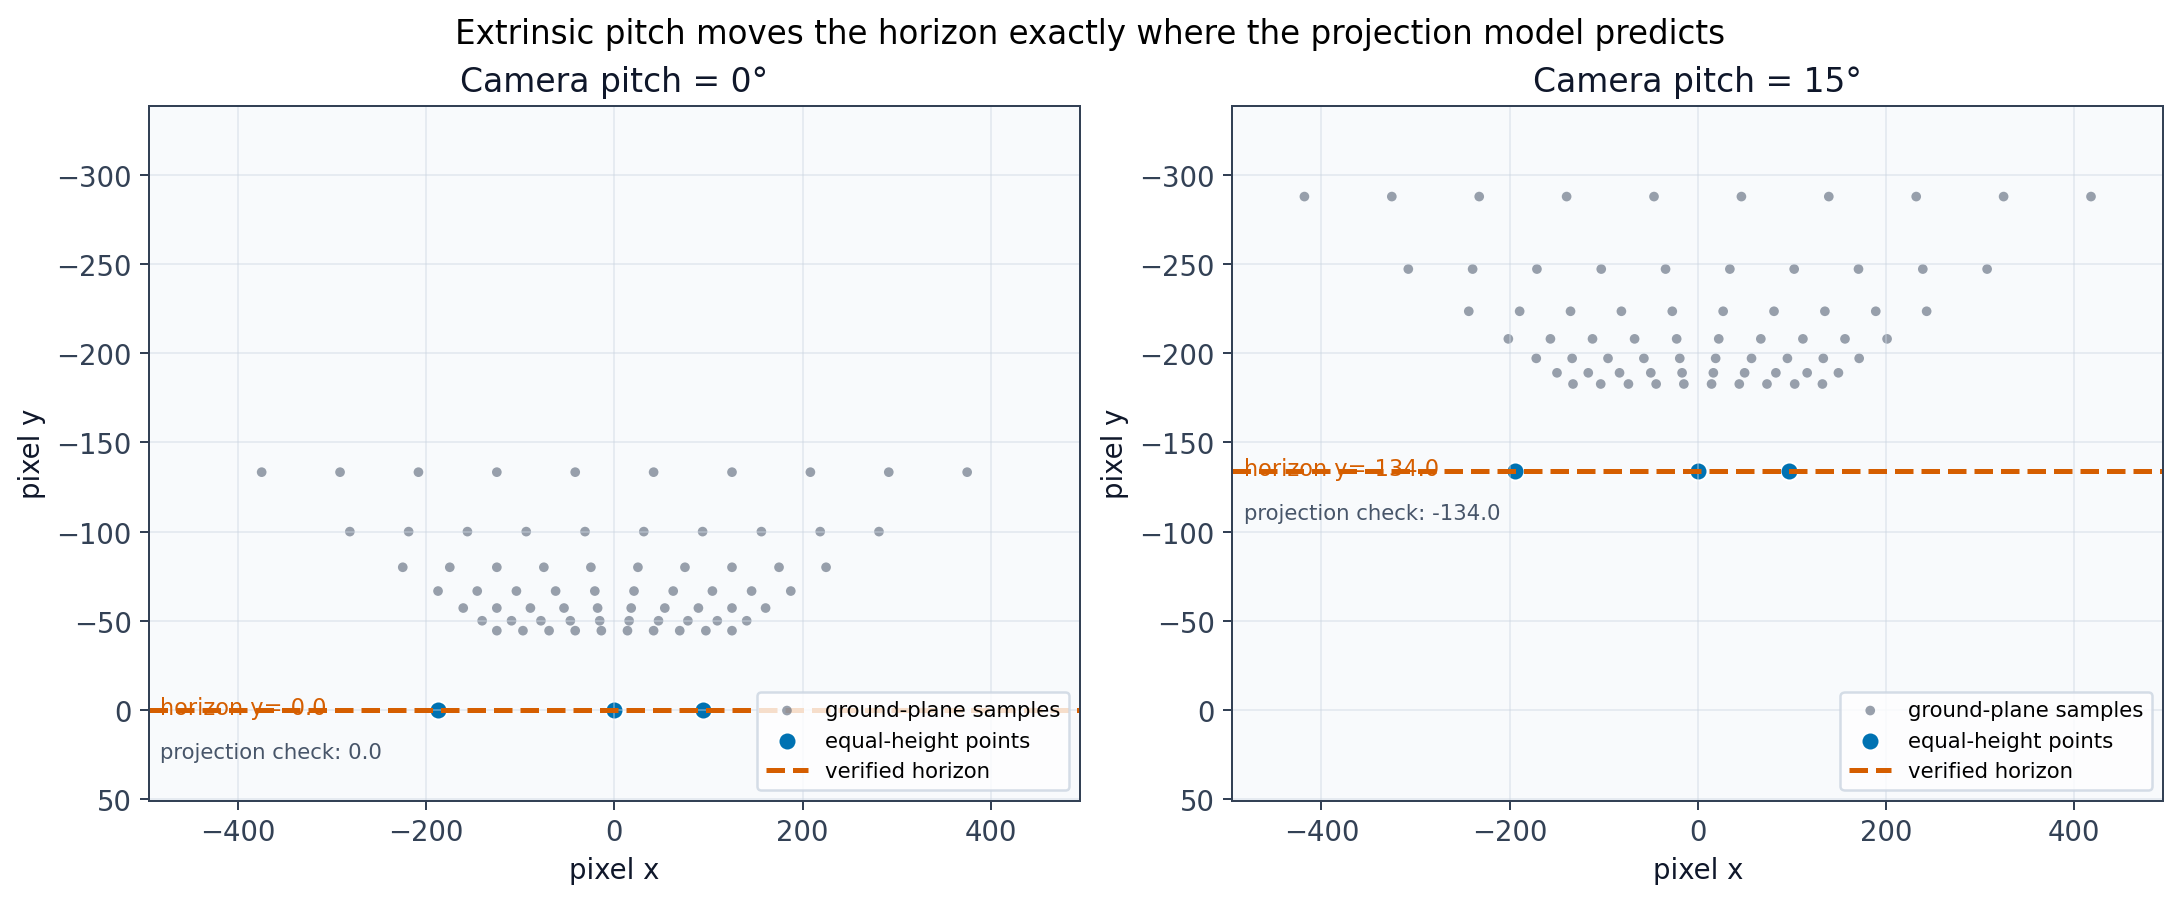

In [5]:
K = make_intrinsics(500.0, 500.0, 0.0, 0.0)
T = torch.tensor([0.0, 1.6, 0.0], dtype=torch.float64)
pitches = [0.0, 15.0]

ground_x = torch.linspace(-4.5, 4.5, 10, dtype=torch.float64)
ground_z = torch.linspace(6.0, 18.0, 7, dtype=torch.float64)
ground_points = torch.tensor([[float(x), 0.0, float(z)] for z in ground_z for x in ground_x], dtype=torch.float64)
horizon_points = torch.tensor([[float(x), float(T[1]), 1500.0] for x in torch.linspace(-6.0, 6.0, 13, dtype=torch.float64)], dtype=torch.float64)
reference_people = torch.tensor([[-3.0, float(T[1]), 8.0], [0.0, float(T[1]), 12.0], [3.0, float(T[1]), 16.0]], dtype=torch.float64)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.9), constrained_layout=True)
panel_data = []
for pitch in pitches:
    R = rotation_x(pitch)
    ground_pixels, _ = project_points(ground_points, K, R, T)
    equal_height_pixels, _ = project_points(reference_people, K, R, T)
    far_pixels, _ = project_points(horizon_points, K, R, T)
    horizon_y = float(far_pixels[:, 1].mean())
    verified_horizon_y = -float(K[1, 1]) * math.tan(math.radians(pitch))
    panel_data.append((pitch, ground_pixels, equal_height_pixels, horizon_y, verified_horizon_y))

all_x = torch.cat([item[1][:, 0] for item in panel_data] + [item[2][:, 0] for item in panel_data])
all_y = torch.cat(
    [item[1][:, 1] for item in panel_data]
    + [item[2][:, 1] for item in panel_data]
    + [torch.tensor([item[3], item[4]], dtype=torch.float64) for item in panel_data]
)
pad_x = 0.07 * float(all_x.max() - all_x.min()) + 18.0
pad_y = 0.10 * float(all_y.max() - all_y.min()) + 22.0
xlim = (float(all_x.min()) - pad_x, float(all_x.max()) + pad_x)
ylim = (float(all_y.min()) - pad_y, float(all_y.max()) + pad_y)

for ax, (pitch, ground_pixels, equal_height_pixels, horizon_y, verified_horizon_y) in zip(axes, panel_data, strict=True):
    ax.scatter(ground_pixels[:, 0], ground_pixels[:, 1], s=15, color=mcolors.to_rgba(COLORS["gray"], 0.55), edgecolor="none", label="ground-plane samples")
    ax.scatter(equal_height_pixels[:, 0], equal_height_pixels[:, 1], s=52, color=COLORS["blue"], edgecolor="white", linewidth=0.8, label="equal-height points")
    # With P_C = R(P_W - T), the implemented positive downward pitch places the horizon at y = -f tan(theta).
    ax.axhline(verified_horizon_y, color=COLORS["vermillion"], linestyle="--", lw=2.0, label="verified horizon")
    ax.text(xlim[0] + 12.0, verified_horizon_y - 8.0, f"horizon y={verified_horizon_y:.1f}", color=COLORS["vermillion"], fontsize=9, va="top")
    ax.text(xlim[0] + 12.0, verified_horizon_y + 18.0, f"projection check: {horizon_y:.1f}", color=COLORS["gray"], fontsize=8.5, va="top")
    ax.set_title(f"Camera pitch = {pitch:.0f}°")
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.invert_yaxis()
    light_grid(ax)
    ax.legend(loc="lower right", fontsize=8.5)

fig.suptitle("Extrinsic pitch moves the horizon exactly where the projection model predicts", fontsize=13)
savefig(fig, "04-extrinsics-and-horizon.png")


**Supplemental visualization for MIT Vision Book Section 39.6.**

We projected a small set of equal-height scene points with a level camera and with a 15 degree downward pitch. The dashed line marks the numerically verified horizon height `y_h = -f tan(theta)` under the notebook convention `P_C = R(P_W - T)`, and the displayed image coordinates use the standard image convention where `y` increases downward.


## 39.7 Camera Calibration

Calibration estimates the mapping from known 3D scene points to observed 2D image
points. The chapter first introduces a linear estimate of the projection matrix and then
discusses how to recover more interpretable intrinsic and extrinsic parameters.

### 39.7.1 Direct Linear Transform

DLT solves for a projection matrix by stacking linear equations from several 3D-to-2D
correspondences. The result is determined only up to an overall scale, which is fine for
projective geometry.

### 39.7.2 Recovering Intrinsic and Extrinsic Camera Parameters

Once a projection matrix has been estimated, we still need to factor it into camera
intrinsics and pose. Conceptually, this means separating the left `3x3` calibration part
from the world-to-camera pose terms.

### 39.7.3 Multiplane Calibration Method

Multiplane calibration uses several views of a known planar target to stabilize the
parameter estimates. This is closer to what practical camera-calibration toolkits do.

### 39.7.4 Nonlinear Optimization by Minimizing Reprojection Error

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/reprojection_error.png" alt="MIT Vision Book Figure 39.14" style="width: 62%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.4, Figure 39.14. This original textbook figure shows reprojection error directly on the image plane. It matters because nonlinear refinement usually optimizes camera parameters by minimizing this quantity.</em></p>
</div>

Linear estimates are often only the starting point. A better model is usually obtained by
refining parameters to minimize the distance between observed image points and predicted
image points.

### 39.7.5 A Toy Example

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/office_with_measures_2.jpg" alt="MIT Vision Book Figure 39.15" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.15. This original textbook figure shows the real office scene used in the toy calibration example. It matters because the later 3D annotations are grounded in these measurements.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/correspondences_img.png" alt="MIT Vision Book Figure 39.16" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.16. This original textbook figure pairs image observations with measured 3D coordinates. It matters because calibration needs matched 3D scene points and 2D image points.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/result_toymodel_3dscene_and_estimated_camera_b.png" alt="MIT Vision Book Figure 39.17" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.17. This original textbook figure visualizes the inferred camera location from several viewpoints. It matters because a good calibration should produce a physically plausible camera pose.</em></p>
</div>

The office example shows the whole calibration story end to end: measure some 3D
positions, annotate the corresponding image points, estimate the camera, and then inspect
whether the result is plausible.


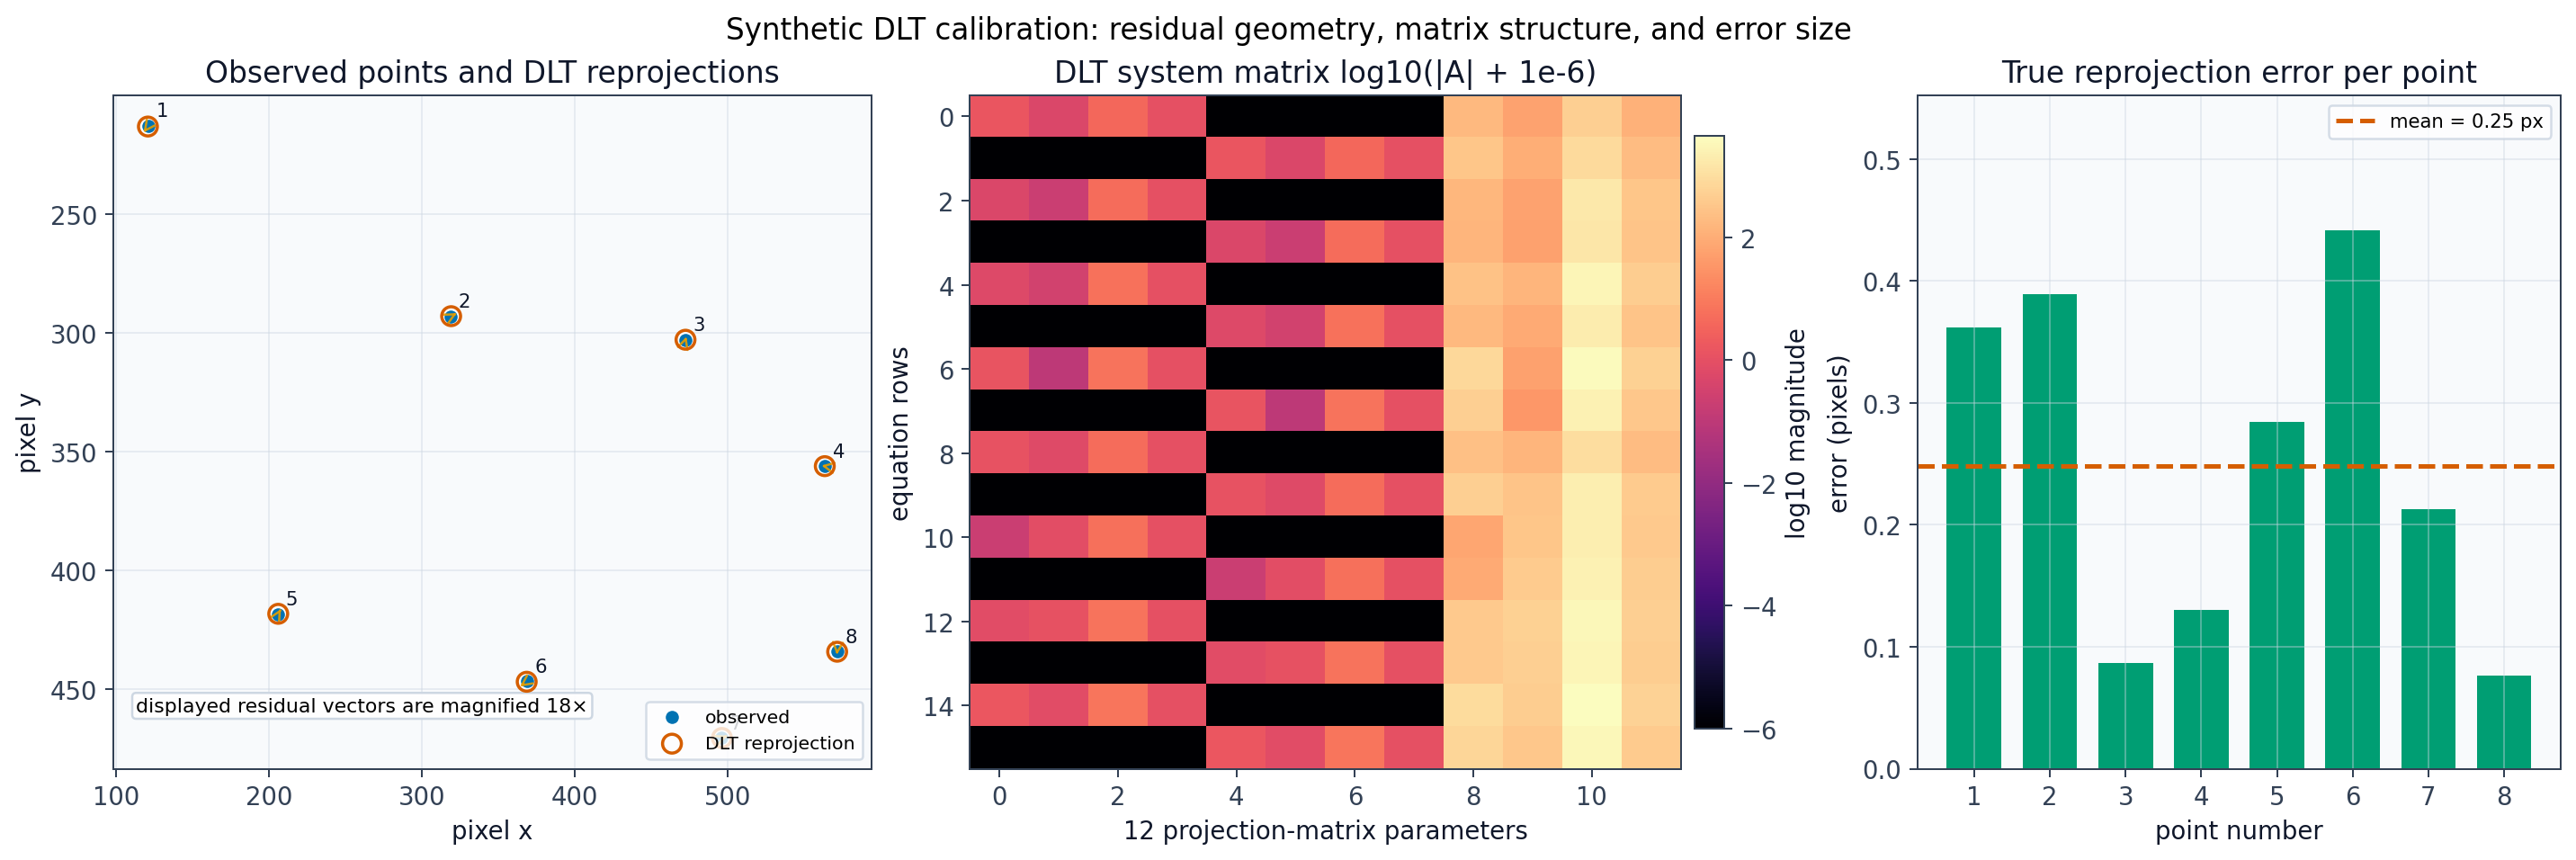

Estimated projection matrix (normalized):
tensor([[ 5.9194e-01, -7.8249e-02,  3.4478e-01, -7.8726e-02],
        [-4.3553e-02,  5.6133e-01,  3.2921e-01, -3.0505e-01],
        [-1.3287e-04, -1.7602e-04,  7.8526e-04,  3.0855e-04]],
       dtype=torch.float64)
Mean reprojection error: 0.248 px


In [6]:
world_points = torch.tensor(
    [
        [-1.5, -0.5,  4.0],
        [-0.5, -0.2,  5.2],
        [ 0.6, -0.3,  6.4],
        [ 1.4,  0.1,  7.0],
        [-1.2,  0.7,  5.0],
        [-0.2,  0.9,  6.0],
        [ 0.8,  1.1,  6.8],
        [ 1.6,  0.8,  8.0],
    ],
    dtype=torch.float64,
)

K_true = make_intrinsics(820.0, 790.0, 320.0, 240.0)
R_true = rotation_y(8.0) @ rotation_x(-12.0)
T_true = torch.tensor([0.3, 0.6, -0.4], dtype=torch.float64)

observed_pixels, _ = project_points(world_points, K_true, R_true, T_true)
noisy_pixels = observed_pixels + 0.8 * torch.tensor(
    [[0.5, -0.3], [-0.4, 0.2], [0.1, 0.4], [0.3, -0.5], [-0.2, 0.6], [0.4, -0.1], [-0.3, -0.2], [0.2, 0.3]],
    dtype=torch.float64,
)

M_est = estimate_projection_matrix_dlt(world_points, noisy_pixels)
reproj_clean = project_with_matrix(world_points, M_est)
reproj_error = torch.linalg.norm(reproj_clean - noisy_pixels, dim=1)
A = build_dlt_matrix(world_points, noisy_pixels)
A_display = torch.log10(A.abs() + 1e-6).numpy()
vector_scale = 18.0

fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.2), constrained_layout=True, gridspec_kw={"width_ratios": [1.12, 1.05, 0.95]})

ax = axes[0]
ax.scatter(noisy_pixels[:, 0], noisy_pixels[:, 1], color=COLORS["blue"], s=44, edgecolor="white", linewidth=0.8, label="observed", zorder=3)
ax.scatter(reproj_clean[:, 0], reproj_clean[:, 1], facecolor="none", edgecolor=COLORS["vermillion"], s=70, linewidth=1.4, label="DLT reprojection", zorder=4)
for idx, (obs, pred) in enumerate(zip(noisy_pixels, reproj_clean, strict=True), start=1):
    delta = pred - obs
    vis_end = obs + vector_scale * delta
    ax.annotate("", xy=(float(vis_end[0]), float(vis_end[1])), xytext=(float(obs[0]), float(obs[1])), arrowprops=dict(arrowstyle="->", lw=1.0, color=COLORS["orange"], alpha=0.9))
    ax.text(float(obs[0]) + 5.0, float(obs[1]) - 4.0, str(idx), fontsize=8.5, color="#0f172a")
ax.text(0.03, 0.08, f"displayed residual vectors are magnified {vector_scale:.0f}×", transform=ax.transAxes, ha="left", va="bottom", fontsize=8.8, bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#cbd5e1", alpha=0.95))
ax.set_title("Observed points and DLT reprojections")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.invert_yaxis()
light_grid(ax)
ax.legend(loc="lower right", fontsize=8.2)

ax = axes[1]
im = ax.imshow(A_display, aspect="auto", cmap="magma")
ax.set_title("DLT system matrix log10(|A| + 1e-6)")
ax.set_xlabel("12 projection-matrix parameters")
ax.set_ylabel("equation rows")
cbar = fig.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
cbar.set_label("log10 magnitude", rotation=90)

ax = axes[2]
point_ids = torch.arange(1, len(reproj_error) + 1)
ax.bar(point_ids.numpy(), reproj_error.numpy(), color=COLORS["green"], width=0.72)
mean_error = float(reproj_error.mean())
ax.axhline(mean_error, color=COLORS["vermillion"], linestyle="--", lw=2.0, label=f"mean = {mean_error:.2f} px")
ax.set_title("True reprojection error per point")
ax.set_xlabel("point number")
ax.set_ylabel("error (pixels)")
ax.set_xticks(point_ids.numpy())
ax.set_ylim(0.0, max(float(reproj_error.max()) * 1.25, mean_error * 1.6))
light_grid(ax)
ax.legend(loc="upper right", fontsize=8.5)

fig.suptitle("Synthetic DLT calibration: residual geometry, matrix structure, and error size", fontsize=13)
savefig(fig, "05-dlt-reprojection-demo.png")

print("Estimated projection matrix (normalized):")
print(M_est)
print(f"Mean reprojection error: {reproj_error.mean().item():.3f} px")


**Computational reconstruction related to MIT Vision Book Section 39.7, Figure 39.14.**

We generated synthetic 3D points, projected them with a known camera, added small image noise, built the DLT linear system, and estimated a projection matrix up to scale. The left panel compares observed and predicted image points, the center panel shows the stacked DLT system, and the right panel summarizes reprojection error.


### Personal Toy Example: Measured Meeting-Room Calibration

This personal experiment mirrors the logic of MIT Figures 39.15–39.17 with a different scene: a meeting-room photograph taken by the notebook author, manual scene measurements in centimeters, manually identified `3D-2D` correspondences, normalized DLT camera estimation, reprojection validation, and measured-scene coordinate views.

For this rebuild we keep the local measured-scene coordinate order `(X, Y, Z)`, but interpret it as a **local planter-side floor reference frame** rather than a full architectural room-corner reconstruction.

The local origin `P1` is the left endpoint of the green `61 cm` floor annotation immediately to the left of the planter. From that point:

- `+X` follows the green `61 cm` floor segment from `P1` toward `P3`;
- `+Y` follows the red `28 cm` floor segment from `P3` toward `P4`;
- `+Z` is vertically upward.

Therefore the floor is `Z = 0`. The blue television wall is modeled as the idealized plane `Y = -18 cm` because the cyan `18 cm` floor offset places the wall reference behind `P3`. The left-side reference direction is parallel to `Y`, but the notebook no longer claims that both large walls intersect exactly at `P1`.

The world axes are mutually perpendicular, while their perspective projections in the photograph are generally not 90 degrees apart.


World coordinate convention for the measured scene:
- P1 = local planter-side floor reference, not a proven architectural room corner
- +X follows the 61 cm floor segment from P1 to P3
- +Y follows the 28 cm floor segment from P3 to P4
- +Z is vertically upward
- floor: Z = 0
- idealized blue-wall plane: Y = -18 cm
- W0 is the physical wall-floor reference at the bottom of the yellow 300 cm segment
- P2 is directly above W0, not above P3
- TV points lie on Y = -18 cm
- Table dimensions are measured, but table yaw relative to the local axes was not independently measured
Measurement table used for the final audited measured-scene model (centimeters):


measurement,value_cm,source segment,status
Local X reference P1 -> P3,61.00,Green 61 cm floor annotation,direct
Local Y reference P3 -> P4,28.00,Red 28 cm floor annotation,direct
Local Z reference P3 -> P6,53.00,Red 53 cm vertical planter annotation,direct
Wall offset from P3 to W0,18.00,Cyan 18 cm floor offset,direct
Wall height from W0 to P2,300.00,Yellow 300 cm wall annotation,direct
TV wall span beginning at X=61 on Y=-18,193.00,Green 193 cm annotation,direct
TV width along X,148.00,Green 148 cm annotation along the TV lower edge,direct
TV lower-left X coordinate,83.50,Derived as 61.0 + 22.5,derived
TV lower-right X coordinate,231.50,Derived as 83.5 + 148.0,derived
Table left X visualization coordinate,131.00,Derived as 61.0 + 70.0,derived visualization assumption


Excluded or intentionally limited measurements:
- The table yaw relative to the local X and Y axes was not independently measured, so table corners are excluded from DLT.
- Point 5 remains excluded because the upper-left planter corner is occluded by leaves.
- The TV upper corners remain excluded because the television height was not measured independently.
Point-by-point visual audit:
Point 1 - local floor origin - manually selected from physical endpoint
Point 3 - end of 61 cm X segment - manually selected from physical endpoint
Point 4 - end of 28 cm Y segment - manually selected from physical endpoint
Point 5 - occluded planter upper-left corner - excluded: endpoint ambiguous
Point 6 - top of 53 cm planter vertical - manually selected from physical endpoint
Point 20 - wall-floor reference at bottom of 300 cm segment - manually selected from physical endpoint
Point 2 - top of 300 cm wall reference - manually selected from physical endpoint; derived world coordinate
Point 7 - TV lowe

id,feature,world coordinate,image coordinate,measurement endpoints,coordinate derivation,calibration use,status,exclusion reason
1,local floor origin,"(np.float64(0.0), np.float64(0.0), np.float64(0.0))","(np.float64(18.0), np.float64(810.0))",left endpoint of green 61 cm segment,chosen local reference,used by DLT,manually selected from physical endpoint,-
3,end of 61 cm X segment,"(np.float64(61.0), np.float64(0.0), np.float64(0.0))","(np.float64(178.0), np.float64(790.0))",green 61 cm segment,"P1 + (61,0,0)",used by DLT,manually selected from physical endpoint,-
4,end of 28 cm Y segment,"(np.float64(61.0), np.float64(28.0), np.float64(0.0))","(np.float64(111.0), np.float64(858.0))",red 28 cm segment from P3 to P4,"P3 + (0,28,0)",used by DLT,manually selected from physical endpoint,-
5,occluded planter upper-left corner,"(np.float64(61.0), np.float64(0.0), np.float64(53.0))",-,vertical above P3-side planter corner,unsupported because visible corner is occluded,excluded from DLT,excluded: endpoint ambiguous,occluded by leaves
6,top of 53 cm planter vertical,"(np.float64(61.0), np.float64(0.0), np.float64(53.0))","(np.float64(166.0), np.float64(712.0))",red 53 cm segment from P3 to P6,"P3 + (0,0,53)",used by DLT,manually selected from physical endpoint,-
20,wall-floor reference at bottom of 300 cm segment,"(np.float64(61.0), np.float64(-18.0), np.float64(0.0))","(np.float64(215.0), np.float64(721.0))",cyan 18 cm offset and yellow 300 cm bottom endpoint,"P3 + (0,-18,0)",used by DLT,manually selected from physical endpoint,-
2,top of 300 cm wall reference,"(np.float64(61.0), np.float64(-18.0), np.float64(300.0))","(np.float64(110.0), np.float64(181.0))",yellow 300 cm segment top endpoint,"W0 + (0,0,300)",used by DLT,manually selected from physical endpoint; derived world coordinate,-
7,TV lower-left,"(np.float64(83.5), np.float64(-18.0), np.float64(110.0))","(np.float64(224.0), np.float64(563.0))",centered 148 cm width inside 193 cm span on wall plane,derived world coordinate on Y=-18 plane,used by DLT,mechanically valid derived world coordinate; pixel manually selected,-
8,TV lower-right,"(np.float64(231.5), np.float64(-18.0), np.float64(110.0))","(np.float64(456.0), np.float64(551.0))",centered 148 cm width inside 193 cm span on wall plane,derived world coordinate on Y=-18 plane,used by DLT,mechanically valid derived world coordinate; pixel manually selected,-
9,table back-left visualization point,"(np.float64(131.0), np.float64(80.0), np.float64(75.0))","(np.float64(319.0), np.float64(633.0))","61 cm reference, 70 cm X offset, 98 cm wall setback, 75 cm height",axis-aligned visualization assumption,excluded from DLT,excluded: orientation not measured,table yaw relative to local axes not independently measured


Points retained for DLT: [1, 3, 4, 6, 20, 2, 7, 8]
Points excluded from DLT: [(5, 'occluded by leaves'), (9, 'table yaw relative to local axes not independently measured'), (10, 'table yaw relative to local axes not independently measured'), (11, 'table yaw relative to local axes not independently measured'), (12, 'outside or not reliably visible')]
DLT conditioning diagnostics:
- Retained correspondence count: 8
- Centered 3D rank: 3
- DLT singular values: [   14.7652     6.7073     5.4156     4.5467     3.1309     2.8630
     1.7378     1.3186     0.9036     0.6307     0.2353     0.0680]
- Smallest singular value: 6.795062e-02
- Second-smallest singular value: 2.352989e-01
- Singular-gap ratio: 3.4628
- Condition number: 2.1729e+02
Calibration diagnostics:
- DLT design-matrix rank: 12
- Estimated focal lengths: fx = 364.90, fy = 855.56
- Estimated principal point = (212.39, 1361.47)
- Camera center C = [   -291.34    -265.65    -483.90] cm
- Viewing-direction dot product toward scene

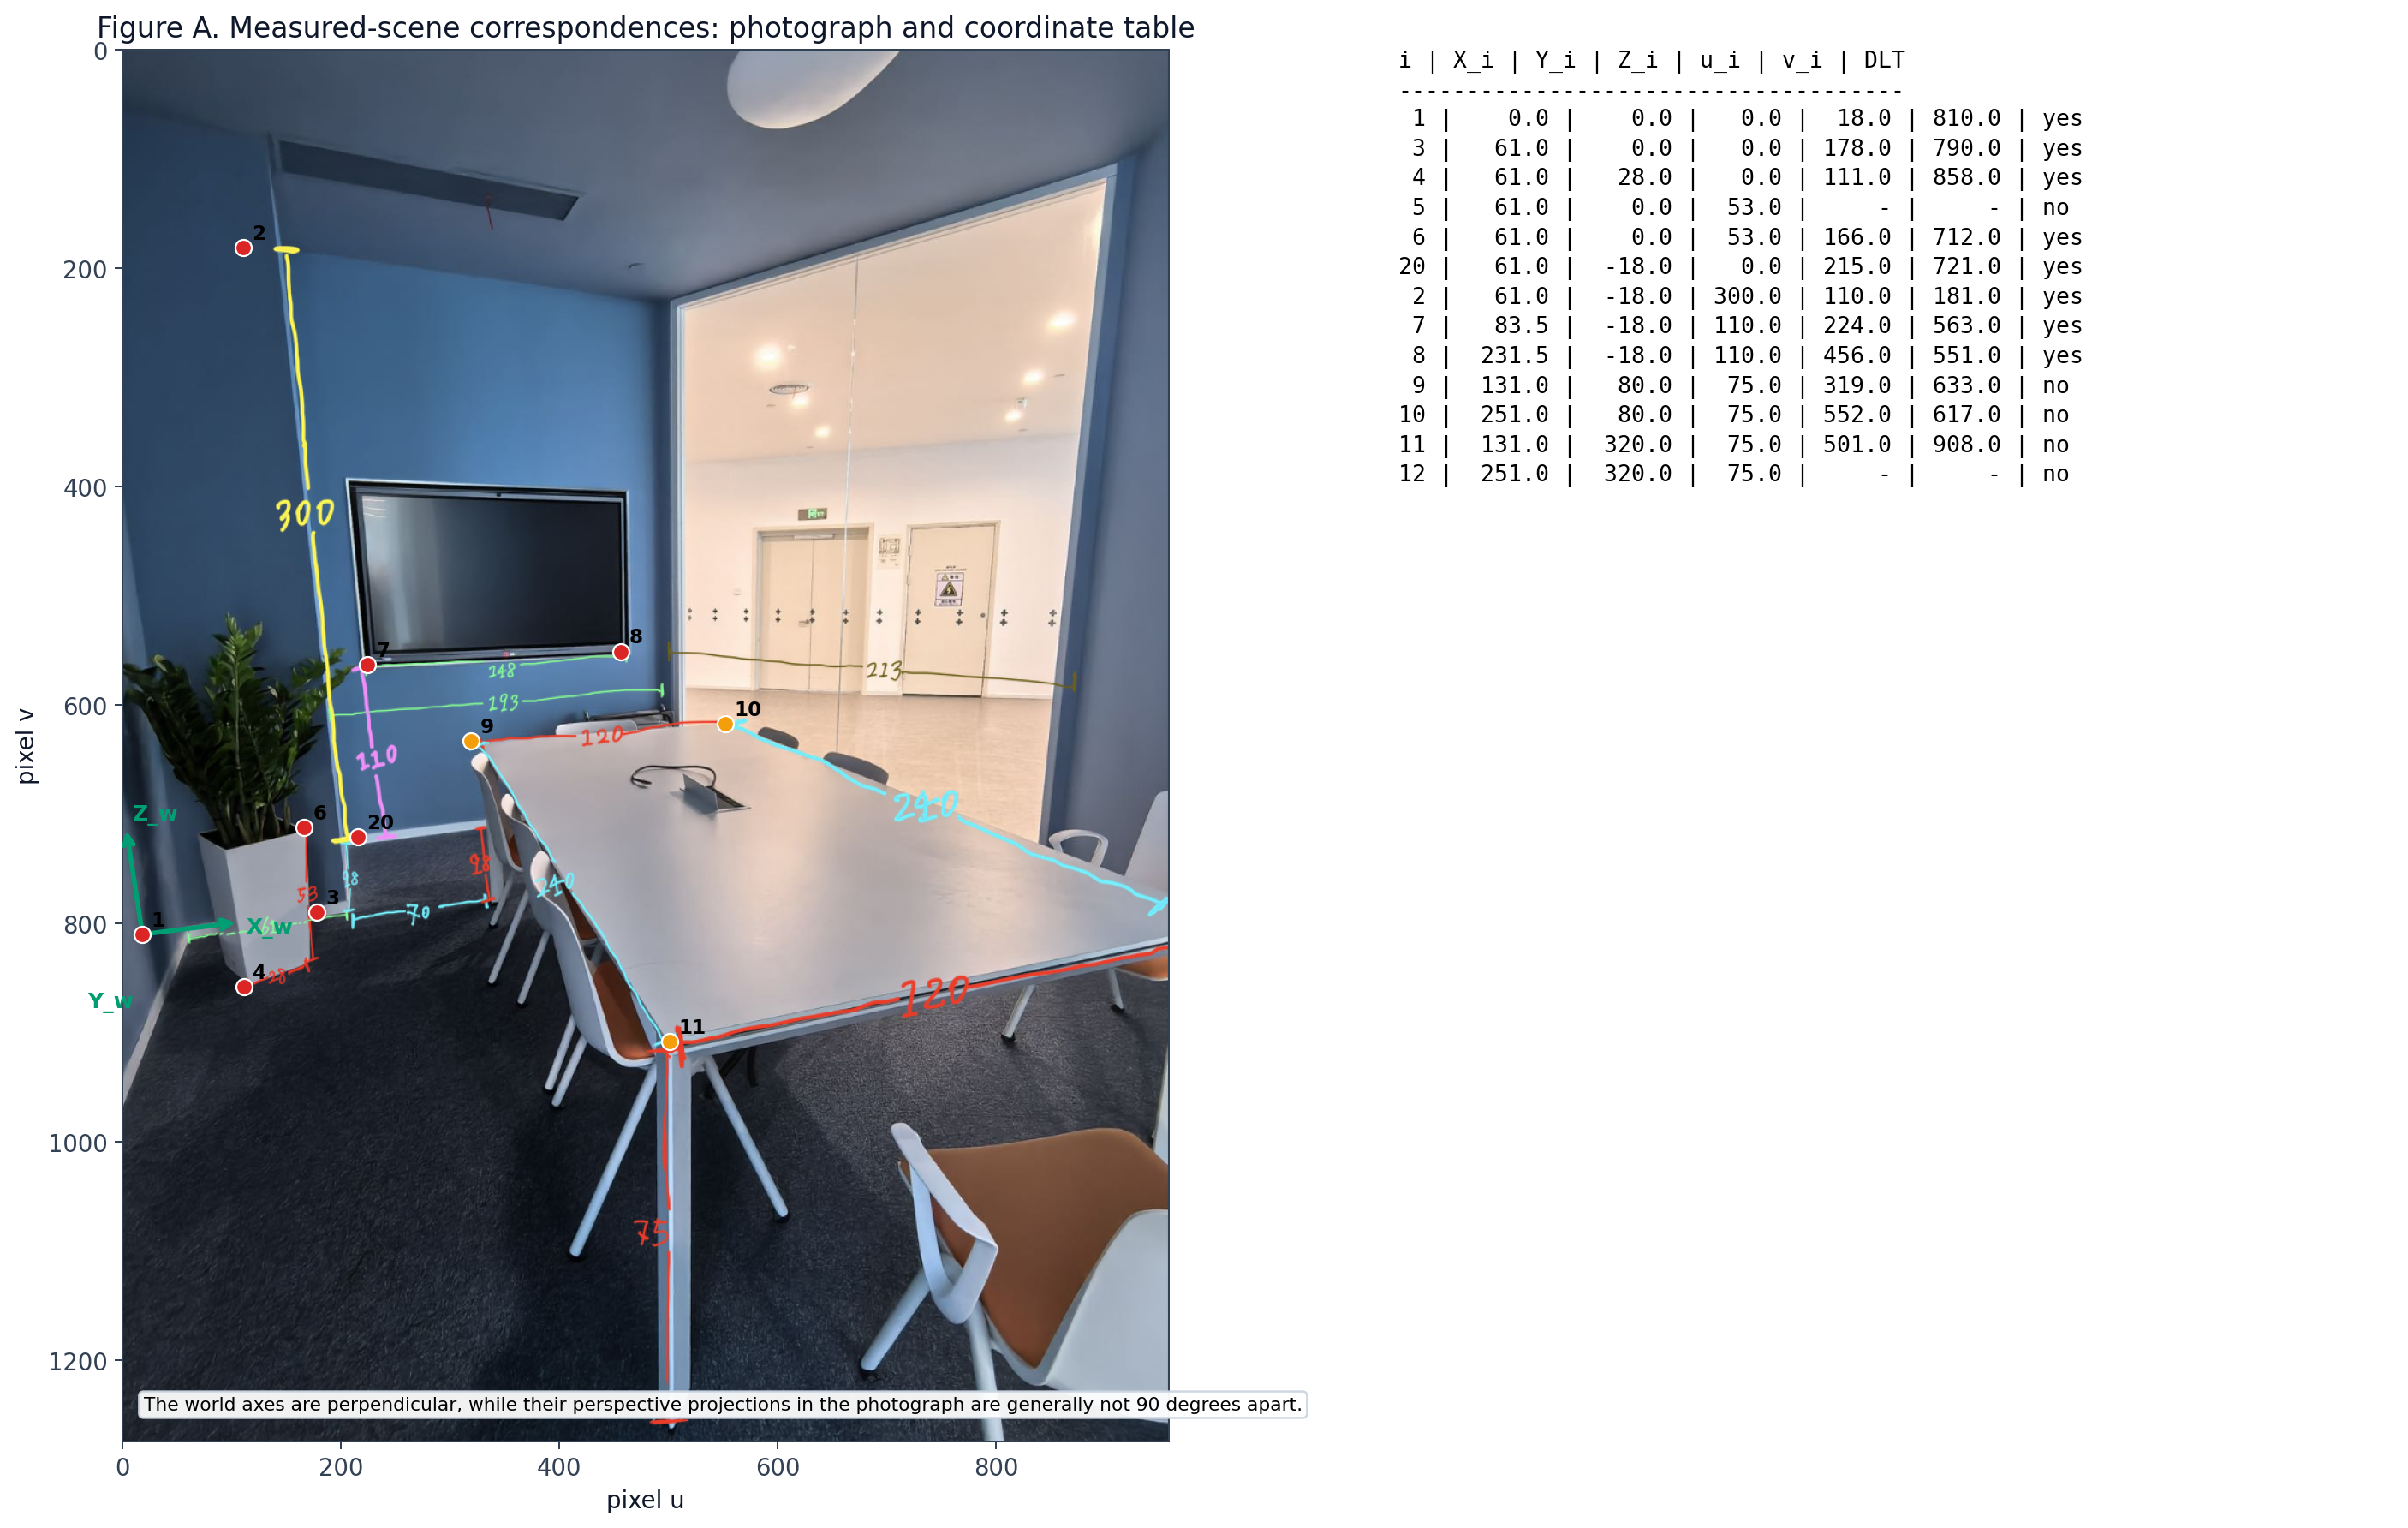

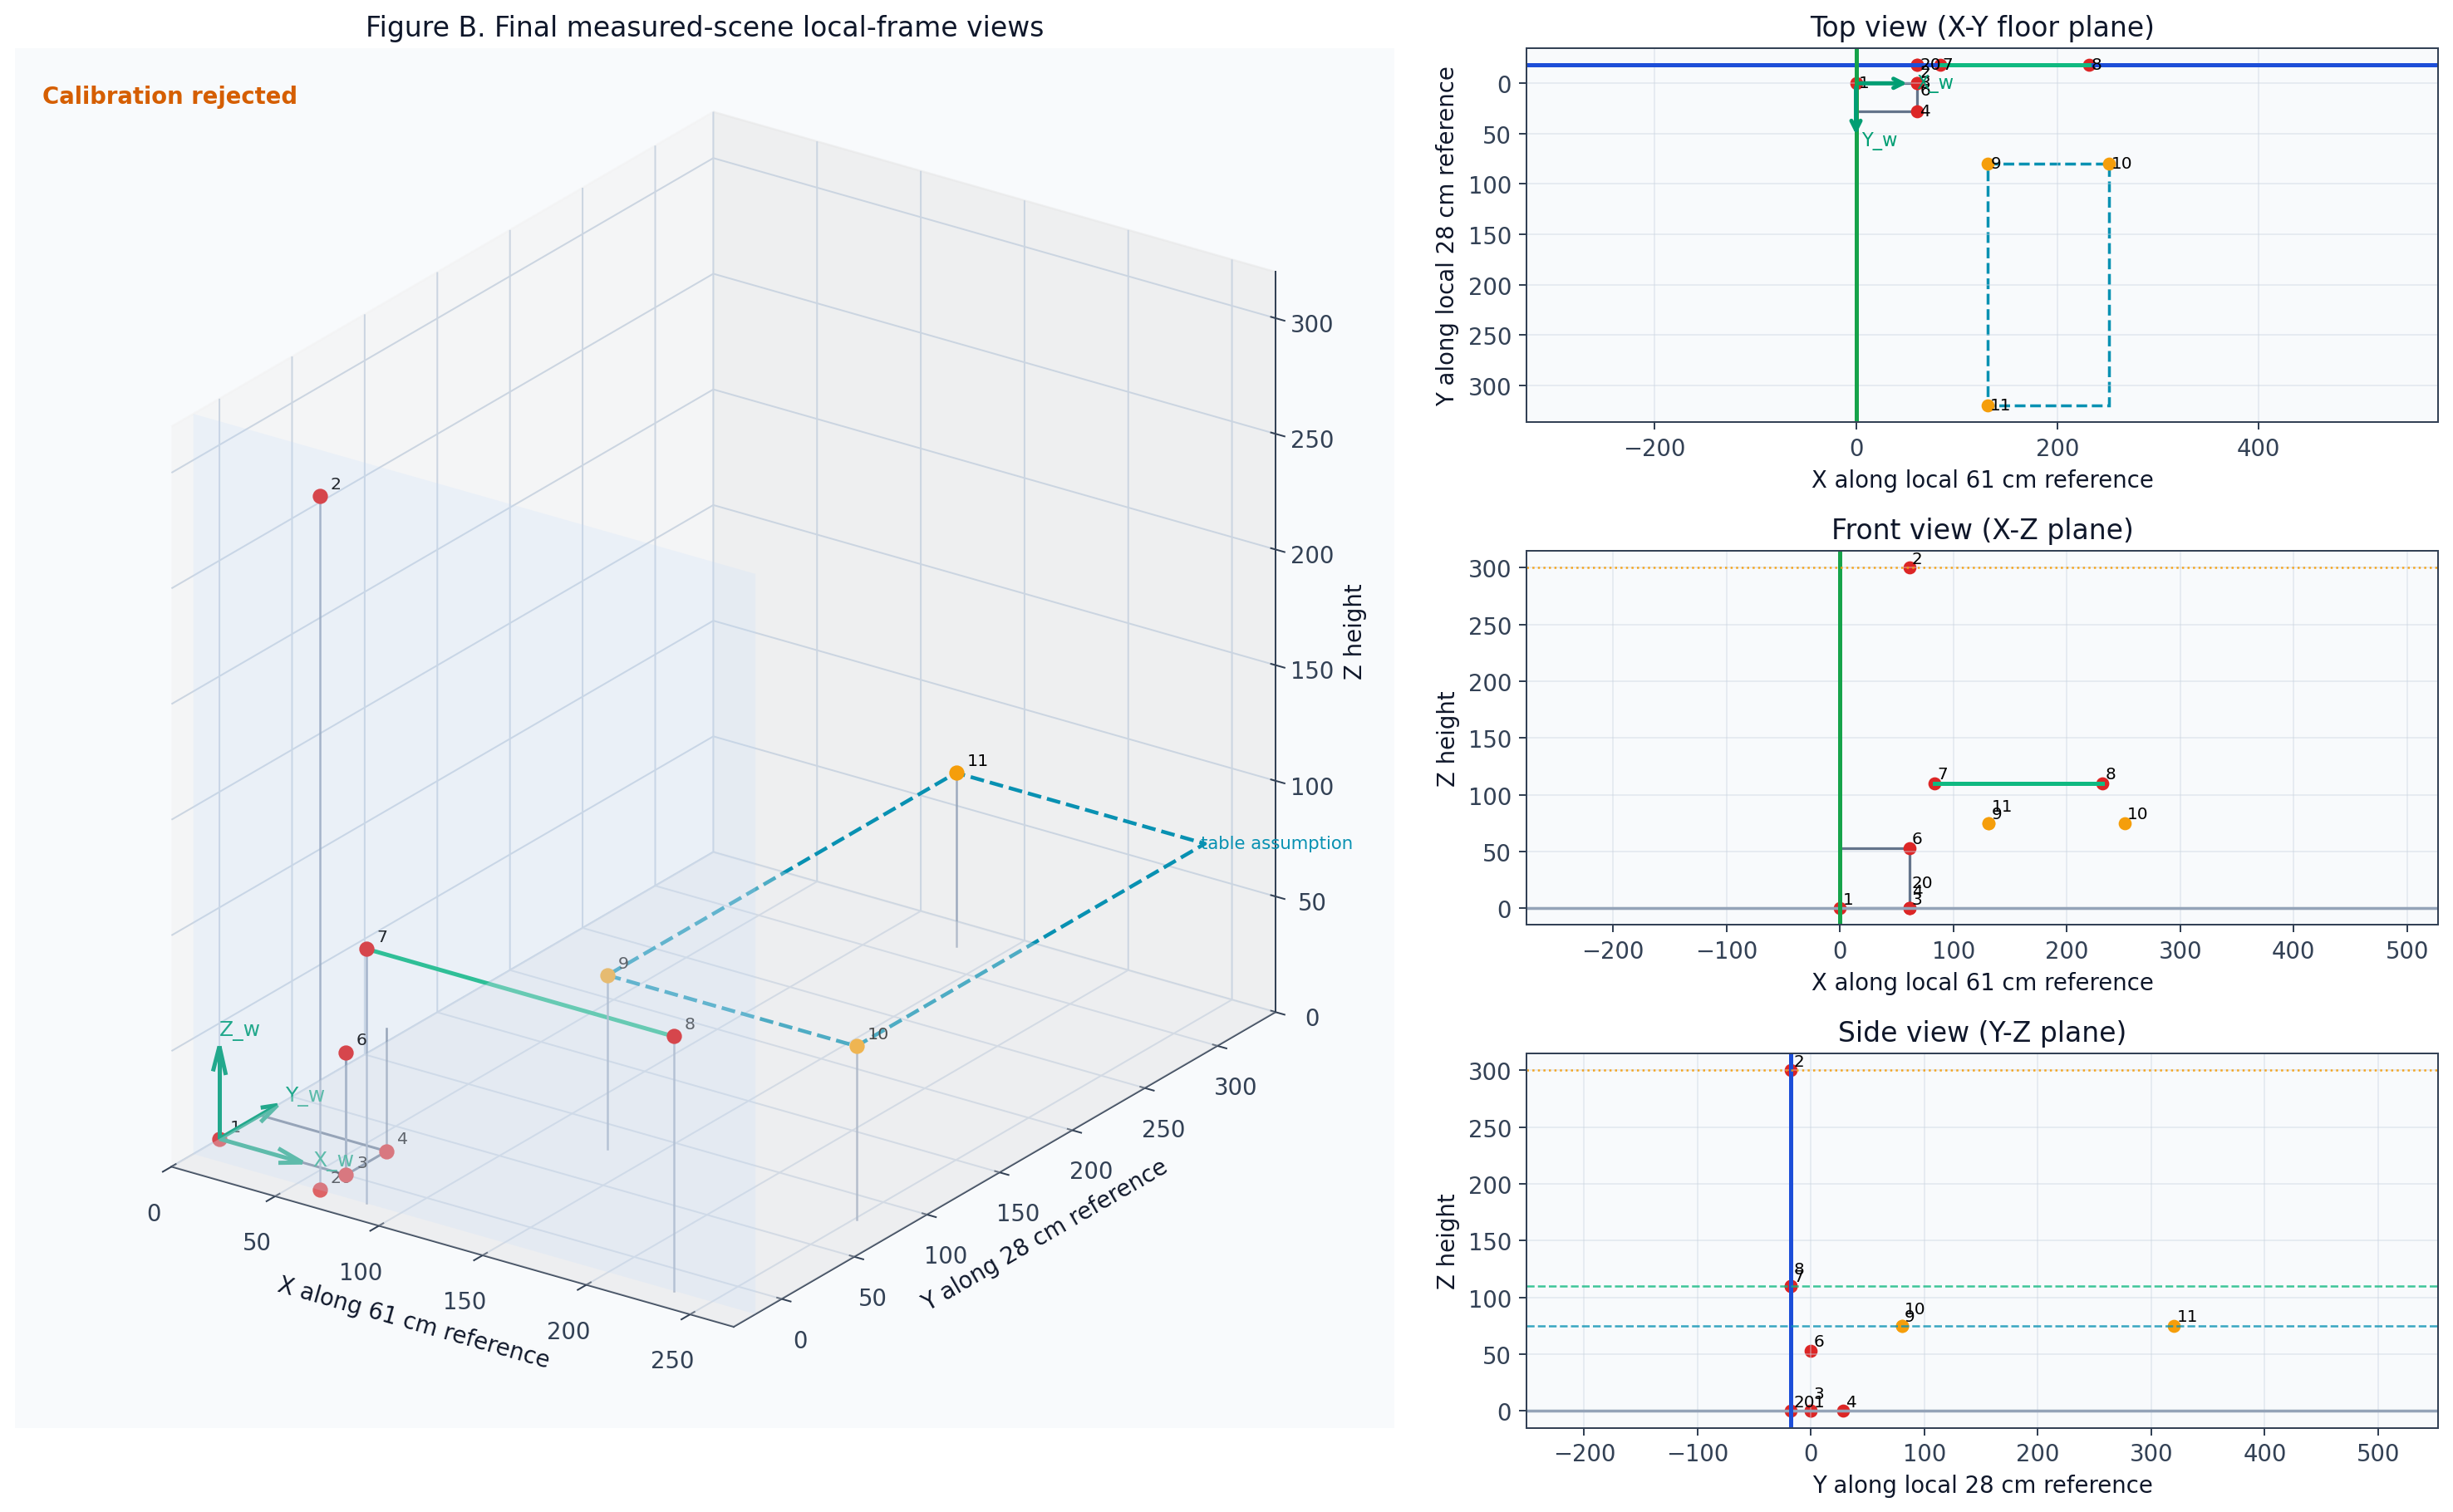

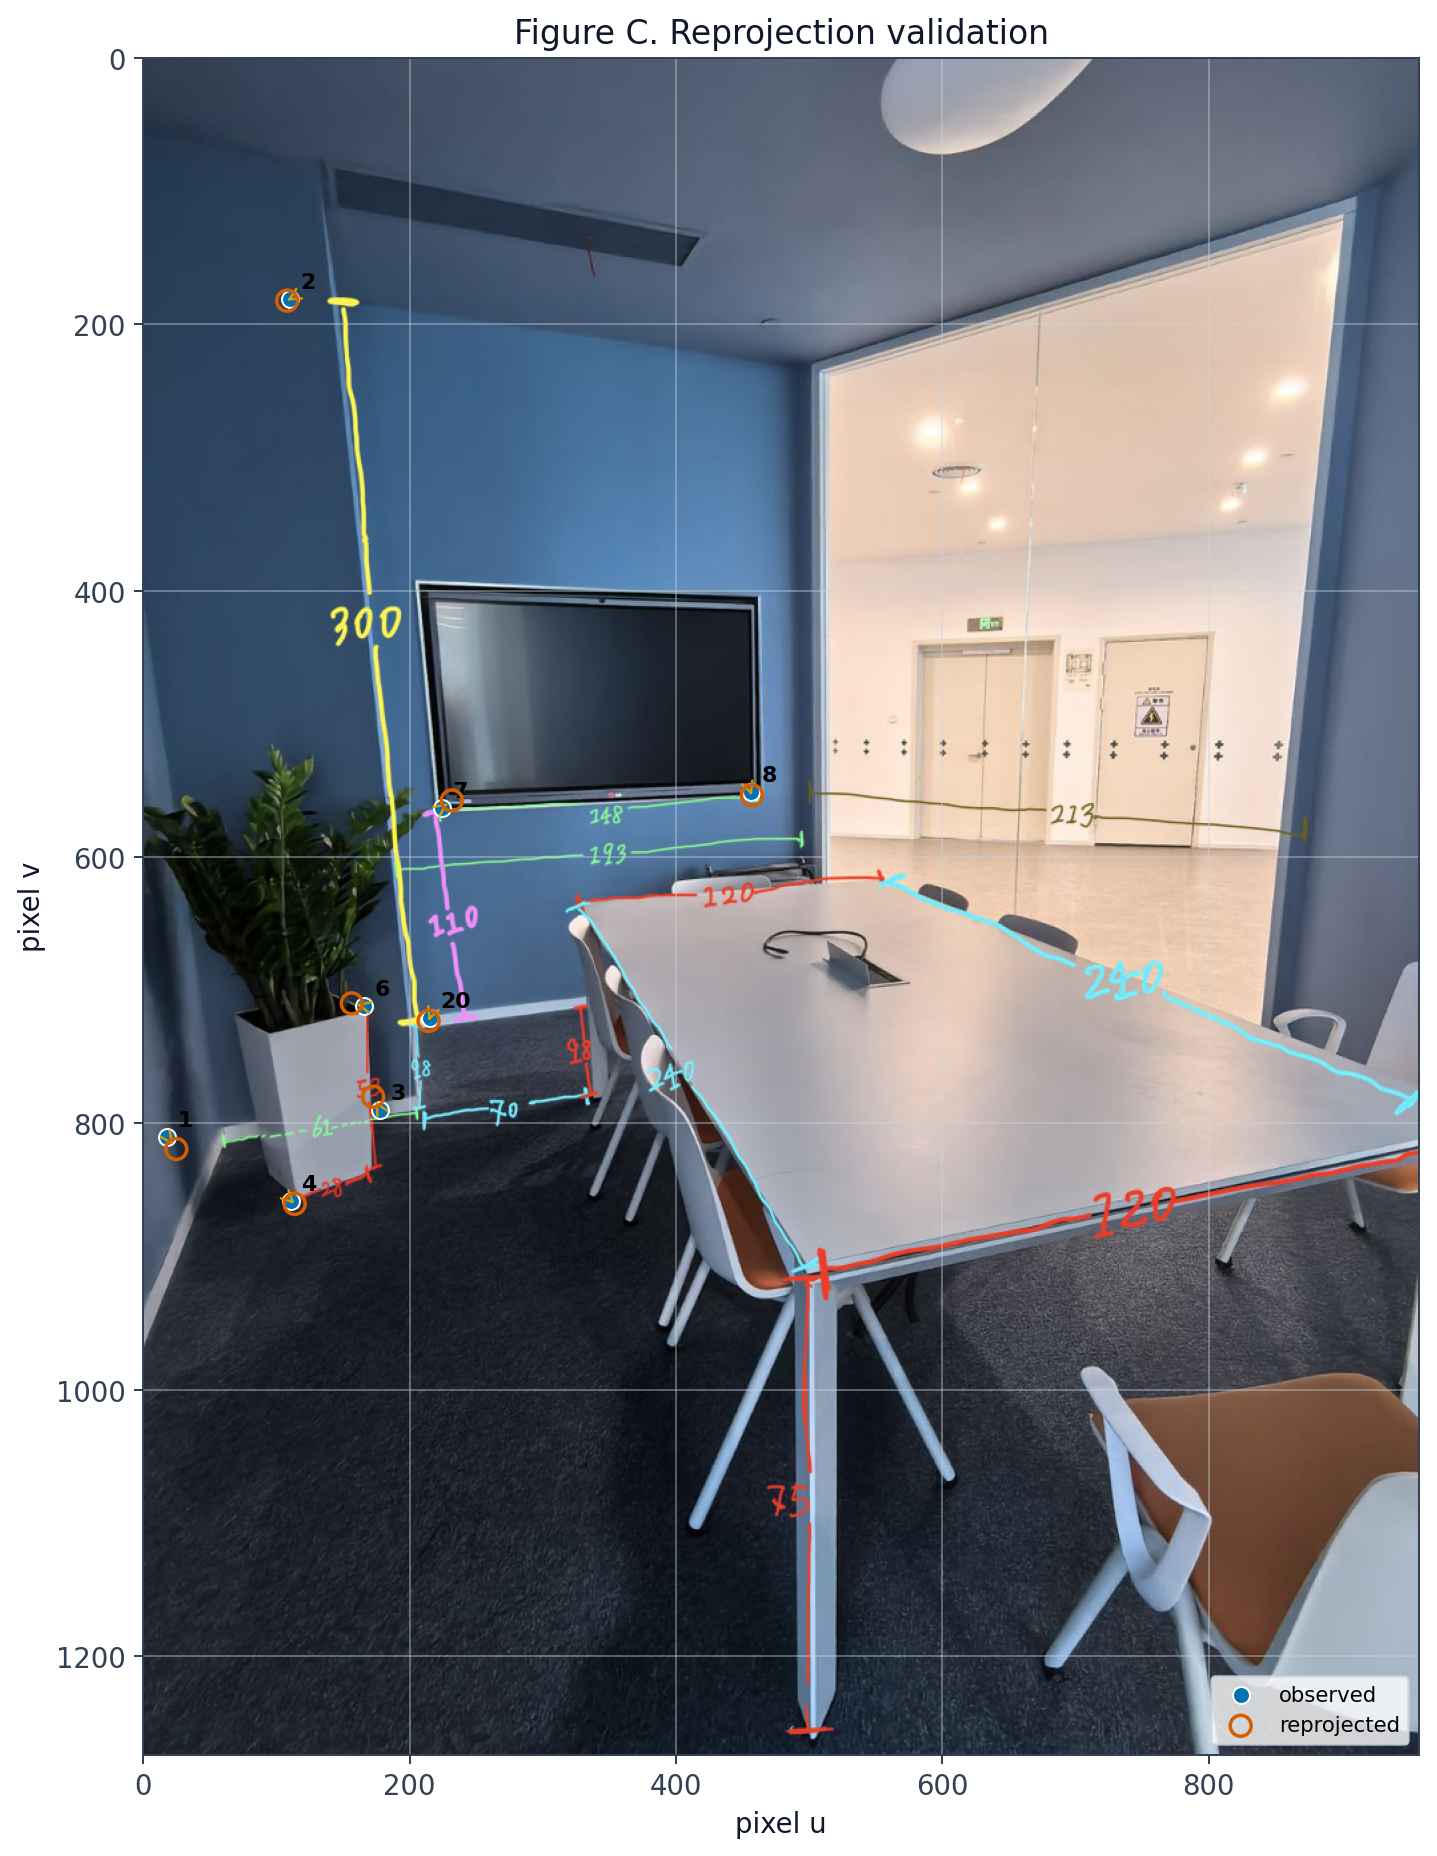

Per-point reprojection summary:


id,"observed (u_i, v_i)","predicted (u_i, v_i)",fit error (px),leave-one-out error (px)
1,"(18.0, 810.0)","(24.7, 819.3)",11.46,71.32
3,"(178.0, 790.0)","(172.5, 780.0)",11.37,16.96
4,"(111.0, 858.0)","(113.6, 860.5)",3.61,186.80
6,"(166.0, 712.0)","(156.5, 709.9)",9.75,11.84
20,"(215.0, 721.0)","(214.2, 723.1)",2.29,9.85
2,"(110.0, 181.0)","(108.0, 182.2)",2.35,246.95
7,"(224.0, 563.0)","(231.7, 557.6)",9.40,28.76
8,"(456.0, 551.0)","(457.0, 553.8)",2.93,126.87


In [7]:
annotated_image_path = CHAPTER_DIR / "biaoding.jpg"
assert annotated_image_path.exists(), f"Missing annotated meeting-room image: {annotated_image_path}"

image = plt.imread(annotated_image_path)
image_height, image_width = image.shape[:2]

reference_x = 61.0
planter_y = 28.0
planter_z = 53.0
wall_offset_y = -18.0
wall_span = 193.0
wall_height_z = 300.0

tv_width = 148.0
tv_bottom_z = 110.0
tv_gap = (wall_span - tv_width) / 2.0
tv_left_x = reference_x + tv_gap
tv_right_x = tv_left_x + tv_width

table_x_offset_from_reference = 70.0
table_width_x = 120.0
table_length_y = 240.0
table_height_z = 75.0
table_left_x = reference_x + table_x_offset_from_reference
table_right_x = table_left_x + table_width_x
table_back_y = wall_offset_y + 98.0
table_front_y = table_back_y + table_length_y

P1 = np.array([0.0, 0.0, 0.0], dtype=np.float64)
P3 = np.array([61.0, 0.0, 0.0], dtype=np.float64)
P4 = np.array([61.0, 28.0, 0.0], dtype=np.float64)
P5 = np.array([61.0, 0.0, 53.0], dtype=np.float64)
P6 = np.array([61.0, 0.0, 53.0], dtype=np.float64)
W0 = np.array([61.0, -18.0, 0.0], dtype=np.float64)
P2 = np.array([61.0, -18.0, 300.0], dtype=np.float64)
TV_lower_left = np.array([83.5, -18.0, 110.0], dtype=np.float64)
TV_lower_right = np.array([231.5, -18.0, 110.0], dtype=np.float64)
table_back_left = np.array([131.0, 80.0, 75.0], dtype=np.float64)
table_back_right = np.array([251.0, 80.0, 75.0], dtype=np.float64)
table_front_left = np.array([131.0, 320.0, 75.0], dtype=np.float64)
table_front_right = np.array([251.0, 320.0, 75.0], dtype=np.float64)

P1_pixel = np.array([18.0, 810.0], dtype=np.float64)
P3_pixel = np.array([178.0, 790.0], dtype=np.float64)
P4_pixel = np.array([111.0, 858.0], dtype=np.float64)
P6_pixel = np.array([166.0, 712.0], dtype=np.float64)
W0_pixel = np.array([215.0, 721.0], dtype=np.float64)
P2_pixel = np.array([110.0, 181.0], dtype=np.float64)
TV_lower_left_pixel = np.array([224.0, 563.0], dtype=np.float64)
TV_lower_right_pixel = np.array([456.0, 551.0], dtype=np.float64)
table_back_left_pixel = np.array([319.0, 633.0], dtype=np.float64)
table_back_right_pixel = np.array([552.0, 617.0], dtype=np.float64)
table_front_left_pixel = np.array([501.0, 908.0], dtype=np.float64)

assert np.allclose(P1, (0.0, 0.0, 0.0))
assert np.allclose(P3 - P1, (61.0, 0.0, 0.0))
assert np.allclose(P4 - P3, (0.0, 28.0, 0.0))
assert np.allclose(P6 - P3, (0.0, 0.0, 53.0))
assert np.allclose(W0, (61.0, -18.0, 0.0))
assert np.allclose(P2, (61.0, -18.0, 300.0))
assert np.allclose(np.subtract(P2, W0), (0.0, 0.0, 300.0))
assert np.allclose(TV_lower_left, (83.5, -18.0, 110.0))
assert np.allclose(TV_lower_right, (231.5, -18.0, 110.0))
assert np.isclose(TV_lower_right[0] - TV_lower_left[0], 148.0)
assert np.isclose(TV_lower_left[1], -18.0)
assert np.isclose(TV_lower_right[1], -18.0)
assert np.isclose(TV_lower_left[2], 110.0)
assert np.isclose(TV_lower_right[2], 110.0)
assert np.allclose(table_back_left, (131.0, 80.0, 75.0))
assert np.allclose(table_back_right, (251.0, 80.0, 75.0))
assert np.allclose(table_front_left, (131.0, 320.0, 75.0))
assert np.allclose(table_front_right, (251.0, 320.0, 75.0))
assert np.isclose(table_back_right[0] - table_back_left[0], 120.0)
assert np.isclose(table_front_left[1] - table_back_left[1], 240.0)

print("World coordinate convention for the measured scene:")
print("- P1 = local planter-side floor reference, not a proven architectural room corner")
print("- +X follows the 61 cm floor segment from P1 to P3")
print("- +Y follows the 28 cm floor segment from P3 to P4")
print("- +Z is vertically upward")
print("- floor: Z = 0")
print("- idealized blue-wall plane: Y = -18 cm")
print("- W0 is the physical wall-floor reference at the bottom of the yellow 300 cm segment")
print("- P2 is directly above W0, not above P3")
print("- TV points lie on Y = -18 cm")
print("- Table dimensions are measured, but table yaw relative to the local axes was not independently measured")

measurement_rows = [
    {"measurement": "Local X reference P1 -> P3", "value_cm": reference_x, "source segment": "Green 61 cm floor annotation", "status": "direct"},
    {"measurement": "Local Y reference P3 -> P4", "value_cm": planter_y, "source segment": "Red 28 cm floor annotation", "status": "direct"},
    {"measurement": "Local Z reference P3 -> P6", "value_cm": planter_z, "source segment": "Red 53 cm vertical planter annotation", "status": "direct"},
    {"measurement": "Wall offset from P3 to W0", "value_cm": 18.0, "source segment": "Cyan 18 cm floor offset", "status": "direct"},
    {"measurement": "Wall height from W0 to P2", "value_cm": wall_height_z, "source segment": "Yellow 300 cm wall annotation", "status": "direct"},
    {"measurement": "TV wall span beginning at X=61 on Y=-18", "value_cm": wall_span, "source segment": "Green 193 cm annotation", "status": "direct"},
    {"measurement": "TV width along X", "value_cm": tv_width, "source segment": "Green 148 cm annotation along the TV lower edge", "status": "direct"},
    {"measurement": "TV lower-left X coordinate", "value_cm": tv_left_x, "source segment": "Derived as 61.0 + 22.5", "status": "derived"},
    {"measurement": "TV lower-right X coordinate", "value_cm": tv_right_x, "source segment": "Derived as 83.5 + 148.0", "status": "derived"},
    {"measurement": "Table left X visualization coordinate", "value_cm": table_left_x, "source segment": "Derived as 61.0 + 70.0", "status": "derived visualization assumption"},
    {"measurement": "Table back Y visualization coordinate", "value_cm": table_back_y, "source segment": "Derived as -18.0 + 98.0", "status": "derived visualization assumption"},
    {"measurement": "Table width along X", "value_cm": table_width_x, "source segment": "Red 120 cm annotation", "status": "direct"},
    {"measurement": "Table length along Y", "value_cm": table_length_y, "source segment": "Cyan 240 cm annotation", "status": "direct"},
    {"measurement": "Table height along Z", "value_cm": table_height_z, "source segment": "Red 75 cm annotation", "status": "direct"},
]

excluded_measurements = [
    "The table yaw relative to the local X and Y axes was not independently measured, so table corners are excluded from DLT.",
    "Point 5 remains excluded because the upper-left planter corner is occluded by leaves.",
    "The TV upper corners remain excluded because the television height was not measured independently.",
]

print("Measurement table used for the final audited measured-scene model (centimeters):")
render_html_table(measurement_rows, ["measurement", "value_cm", "source segment", "status"])
print("Excluded or intentionally limited measurements:")
for item in excluded_measurements:
    print(f"- {item}")

point_records = [
    {"id": 1, "feature": "local floor origin", "world": tuple(P1), "pixel": tuple(P1_pixel), "measurement endpoints": "left endpoint of green 61 cm segment", "coordinate derivation": "chosen local reference", "calibration use": "used by DLT", "status": "manually selected from physical endpoint", "exclusion reason": ""},
    {"id": 3, "feature": "end of 61 cm X segment", "world": tuple(P3), "pixel": tuple(P3_pixel), "measurement endpoints": "green 61 cm segment", "coordinate derivation": "P1 + (61,0,0)", "calibration use": "used by DLT", "status": "manually selected from physical endpoint", "exclusion reason": ""},
    {"id": 4, "feature": "end of 28 cm Y segment", "world": tuple(P4), "pixel": tuple(P4_pixel), "measurement endpoints": "red 28 cm segment from P3 to P4", "coordinate derivation": "P3 + (0,28,0)", "calibration use": "used by DLT", "status": "manually selected from physical endpoint", "exclusion reason": ""},
    {"id": 5, "feature": "occluded planter upper-left corner", "world": tuple(P5), "pixel": None, "measurement endpoints": "vertical above P3-side planter corner", "coordinate derivation": "unsupported because visible corner is occluded", "calibration use": "excluded from DLT", "status": "excluded: endpoint ambiguous", "exclusion reason": "occluded by leaves"},
    {"id": 6, "feature": "top of 53 cm planter vertical", "world": tuple(P6), "pixel": tuple(P6_pixel), "measurement endpoints": "red 53 cm segment from P3 to P6", "coordinate derivation": "P3 + (0,0,53)", "calibration use": "used by DLT", "status": "manually selected from physical endpoint", "exclusion reason": ""},
    {"id": 20, "feature": "wall-floor reference at bottom of 300 cm segment", "world": tuple(W0), "pixel": tuple(W0_pixel), "measurement endpoints": "cyan 18 cm offset and yellow 300 cm bottom endpoint", "coordinate derivation": "P3 + (0,-18,0)", "calibration use": "used by DLT", "status": "manually selected from physical endpoint", "exclusion reason": ""},
    {"id": 2, "feature": "top of 300 cm wall reference", "world": tuple(P2), "pixel": tuple(P2_pixel), "measurement endpoints": "yellow 300 cm segment top endpoint", "coordinate derivation": "W0 + (0,0,300)", "calibration use": "used by DLT", "status": "manually selected from physical endpoint; derived world coordinate", "exclusion reason": ""},
    {"id": 7, "feature": "TV lower-left", "world": tuple(TV_lower_left), "pixel": tuple(TV_lower_left_pixel), "measurement endpoints": "centered 148 cm width inside 193 cm span on wall plane", "coordinate derivation": "derived world coordinate on Y=-18 plane", "calibration use": "used by DLT", "status": "mechanically valid derived world coordinate; pixel manually selected", "exclusion reason": ""},
    {"id": 8, "feature": "TV lower-right", "world": tuple(TV_lower_right), "pixel": tuple(TV_lower_right_pixel), "measurement endpoints": "centered 148 cm width inside 193 cm span on wall plane", "coordinate derivation": "derived world coordinate on Y=-18 plane", "calibration use": "used by DLT", "status": "mechanically valid derived world coordinate; pixel manually selected", "exclusion reason": ""},
    {"id": 9, "feature": "table back-left visualization point", "world": tuple(table_back_left), "pixel": tuple(table_back_left_pixel), "measurement endpoints": "61 cm reference, 70 cm X offset, 98 cm wall setback, 75 cm height", "coordinate derivation": "axis-aligned visualization assumption", "calibration use": "excluded from DLT", "status": "excluded: orientation not measured", "exclusion reason": "table yaw relative to local axes not independently measured"},
    {"id": 10, "feature": "table back-right visualization point", "world": tuple(table_back_right), "pixel": tuple(table_back_right_pixel), "measurement endpoints": "120 cm table width", "coordinate derivation": "axis-aligned visualization assumption", "calibration use": "excluded from DLT", "status": "excluded: orientation not measured", "exclusion reason": "table yaw relative to local axes not independently measured"},
    {"id": 11, "feature": "table front-left visualization point", "world": tuple(table_front_left), "pixel": tuple(table_front_left_pixel), "measurement endpoints": "240 cm table length", "coordinate derivation": "axis-aligned visualization assumption", "calibration use": "excluded from DLT", "status": "excluded: orientation not measured", "exclusion reason": "table yaw relative to local axes not independently measured"},
    {"id": 12, "feature": "table front-right visualization point", "world": tuple(table_front_right), "pixel": None, "measurement endpoints": "120 cm width and 240 cm length", "coordinate derivation": "axis-aligned visualization assumption", "calibration use": "excluded from DLT", "status": "excluded: endpoint ambiguous and orientation not measured", "exclusion reason": "outside or not reliably visible"},
]

assert len({row["id"] for row in point_records}) == len(point_records), "Point IDs must be unique."
for row in point_records:
    world = np.asarray(row["world"], dtype=np.float64)
    assert np.all(np.isfinite(world)), f"World coordinates must be finite for point {row['id']}"
    if row["pixel"] is not None:
        pixel = np.asarray(row["pixel"], dtype=np.float64)
        assert np.all(np.isfinite(pixel)), f"Pixel coordinates must be finite for point {row['id']}"
        assert 0.0 <= pixel[0] < image_width and 0.0 <= pixel[1] < image_height, f"Point {row['id']} must lie inside the image."

floor_point_ids = {1, 3, 4, 20}
blue_wall_point_ids = {20, 2, 7, 8}
for row in point_records:
    X_i, Y_i, Z_i = row["world"]
    if row["id"] in floor_point_ids:
        assert np.isclose(Z_i, 0.0), f"Floor point {row['id']} must satisfy Z = 0"
    if row["id"] in blue_wall_point_ids:
        assert np.isclose(Y_i, -18.0), f"Blue-wall point {row['id']} must satisfy Y = -18"

print("Point-by-point visual audit:")
for row in point_records:
    print(f"Point {row['id']} - {row['feature']} - {row['status']}")

print("Audited point table:")
audit_rows = []
for row in point_records:
    audit_rows.append(
        {
            "id": row["id"],
            "feature": row["feature"],
            "world coordinate": row["world"],
            "image coordinate": row["pixel"] if row["pixel"] is not None else "-",
            "measurement endpoints": row["measurement endpoints"],
            "coordinate derivation": row["coordinate derivation"],
            "calibration use": row["calibration use"],
            "status": row["status"],
            "exclusion reason": row["exclusion reason"] if row["exclusion reason"] else "-",
        }
    )
render_html_table(
    audit_rows,
    ["id", "feature", "world coordinate", "image coordinate", "measurement endpoints", "coordinate derivation", "calibration use", "status", "exclusion reason"],
)

calibration_points = [row for row in point_records if row["calibration use"] == "used by DLT"]
excluded_from_dlt = [row for row in point_records if row["calibration use"] != "used by DLT"]
print("Points retained for DLT:", [row["id"] for row in calibration_points])
print("Points excluded from DLT:", [(row["id"], row["exclusion reason"]) for row in excluded_from_dlt])

world_points_real = np.asarray([row["world"] for row in calibration_points], dtype=np.float64)
image_points_real = np.asarray([row["pixel"] for row in calibration_points], dtype=np.float64)
point_numbers = [row["id"] for row in calibration_points]
assert world_points_real.shape[0] == image_points_real.shape[0]
assert world_points_real.shape[0] == len(point_numbers)

centered_world = world_points_real - world_points_real.mean(axis=0)
_, singular_values_world, _ = np.linalg.svd(centered_world, full_matrices=False)
coordinate_rank = int(np.sum(singular_values_world > 1e-6))

projection_real = None
reprojected_points = None
reprojection_error = None
leave_one_out_errors = None
dlt_matrix = None
dlt_singular_values = None
smallest_sv = float("nan")
second_smallest_sv = float("nan")
singular_gap_ratio = float("nan")
condition_number = float("nan")
mean_error = float("nan")
median_error = float("nan")
rms_error = float("nan")
max_error = float("nan")
worst_point_id = None
principal_point = (float("nan"), float("nan"))
fx_est = float("nan")
fy_est = float("nan")
camera_center_real = np.full(3, np.nan)
view_direction_world = np.full(3, np.nan)
viewing_direction_dot = float("nan")
positive_depth_ratio = 0.0
rotation_det = float("nan")
orthogonality_error = float("nan")
dlt_rank = 0
calibration_status = "skipped"
full_dlt_ran = len(calibration_points) >= 6 and coordinate_rank >= 3

camera_checks = {
    "enough_points": len(calibration_points) >= 6,
    "noncoplanar": coordinate_rank >= 3,
    "strong_singular_gap": False,
    "principal_point_inside_image": False,
    "positive_focal_lengths": False,
    "camera_position_plausible": False,
    "viewing_direction_toward_scene": False,
    "positive_depth_ratio": False,
    "reprojection_error_reasonable": False,
    "leave_one_out_stable": False,
    "rotation_proper": False,
    "rotation_orthogonal": False,
}

if full_dlt_ran:
    projection_real, dlt_matrix = estimate_projection_matrix_normalized_dlt(world_points_real, image_points_real)
    dlt_rank = int(np.linalg.matrix_rank(dlt_matrix))
    _, dlt_singular_values, _ = np.linalg.svd(dlt_matrix, full_matrices=False)
    smallest_sv = float(dlt_singular_values[-1])
    second_smallest_sv = float(dlt_singular_values[-2])
    singular_gap_ratio = float(second_smallest_sv / max(smallest_sv, 1e-12))
    condition_number = float(dlt_singular_values[0] / max(smallest_sv, 1e-12))

    reprojected_points = project_with_projection_matrix(world_points_real, projection_real)
    reprojection_error = np.linalg.norm(reprojected_points - image_points_real, axis=1)
    mean_error = float(reprojection_error.mean())
    median_error = float(np.median(reprojection_error))
    rms_error = float(np.sqrt(np.mean(reprojection_error ** 2)))
    max_error = float(reprojection_error.max())
    worst_point_id = point_numbers[int(np.argmax(reprojection_error))]

    intrinsics_raw, rotation_raw, translation_raw, camera_center_raw = decompose_projection_matrix(projection_real)
    sign_matrix_report = np.diag([
        -1.0 if intrinsics_raw[0, 0] < 0.0 else 1.0,
        -1.0 if intrinsics_raw[1, 1] < 0.0 else 1.0,
        1.0,
    ])
    intrinsics_real = intrinsics_raw @ sign_matrix_report
    rotation_real = sign_matrix_report @ rotation_raw
    camera_center_real = camera_center_raw.copy()
    rotation_det = float(np.linalg.det(rotation_real))
    orthogonality_error = float(np.linalg.norm(rotation_real @ rotation_real.T - np.eye(3), ord="fro"))
    view_direction_world = rotation_real.T @ np.array([0.0, 0.0, 1.0], dtype=np.float64)
    view_direction_world = view_direction_world / np.linalg.norm(view_direction_world)
    camera_space_points = (rotation_real @ (world_points_real.T - camera_center_real[:, None])).T
    camera_depth_values = camera_space_points[:, 2].copy()
    if camera_depth_values.mean() < 0.0:
        view_direction_world = -view_direction_world
        camera_depth_values = -camera_depth_values
    positive_depth_ratio = float(np.mean(camera_depth_values > 0.0))

    scene_target = world_points_real.mean(axis=0)
    camera_to_scene = scene_target - camera_center_real
    camera_to_scene = camera_to_scene / np.linalg.norm(camera_to_scene)
    viewing_direction_dot = float(np.dot(view_direction_world, camera_to_scene))

    leave_one_out_errors = []
    for holdout_index in range(len(calibration_points)):
        train_mask = np.ones(len(calibration_points), dtype=bool)
        train_mask[holdout_index] = False
        projection_loo, _ = estimate_projection_matrix_normalized_dlt(world_points_real[train_mask], image_points_real[train_mask])
        predicted_holdout = project_with_projection_matrix(world_points_real[[holdout_index]], projection_loo)[0]
        leave_one_out_errors.append(float(np.linalg.norm(predicted_holdout - image_points_real[holdout_index])))
    leave_one_out_errors = np.asarray(leave_one_out_errors, dtype=np.float64)

    principal_point = (float(intrinsics_real[0, 2]), float(intrinsics_real[1, 2]))
    fx_est = float(intrinsics_real[0, 0])
    fy_est = float(intrinsics_real[1, 1])

    camera_checks = {
        "enough_points": len(calibration_points) >= 6,
        "noncoplanar": coordinate_rank >= 3,
        "strong_singular_gap": singular_gap_ratio > 1.5,
        "principal_point_inside_image": 0.0 <= principal_point[0] <= image_width and 0.0 <= principal_point[1] <= image_height,
        "positive_focal_lengths": fx_est > 0.0 and fy_est > 0.0,
        "camera_position_plausible": (-100.0 <= camera_center_real[0] <= 600.0) and (-200.0 <= camera_center_real[1] <= 700.0) and (30.0 <= camera_center_real[2] <= 260.0),
        "viewing_direction_toward_scene": viewing_direction_dot > 0.5,
        "positive_depth_ratio": positive_depth_ratio >= 0.9,
        "reprojection_error_reasonable": mean_error <= 20.0 and max_error <= 50.0,
        "leave_one_out_stable": float(np.mean(leave_one_out_errors)) <= 60.0 and float(np.max(leave_one_out_errors)) <= 150.0,
        "rotation_proper": abs(rotation_det - 1.0) <= 1e-3,
        "rotation_orthogonal": orthogonality_error <= 1e-6,
    }
    calibration_status = "accepted" if all(camera_checks.values()) else "rejected"
else:
    calibration_status = "skipped"

print("DLT conditioning diagnostics:")
print(f"- Retained correspondence count: {len(calibration_points)}")
print(f"- Centered 3D rank: {coordinate_rank}")
if dlt_singular_values is not None:
    print(f"- DLT singular values: {np.array2string(dlt_singular_values, formatter={'float_kind': lambda value: f'{value:10.4f}'})}")
    print(f"- Smallest singular value: {smallest_sv:.6e}")
    print(f"- Second-smallest singular value: {second_smallest_sv:.6e}")
    print(f"- Singular-gap ratio: {singular_gap_ratio:.4f}")
    print(f"- Condition number: {condition_number:.4e}")
else:
    print("- DLT not run because too few reliable non-degenerate correspondences remain.")

print("Calibration diagnostics:")
print(f"- DLT design-matrix rank: {dlt_rank}")
if full_dlt_ran:
    print(f"- Estimated focal lengths: fx = {fx_est:.2f}, fy = {fy_est:.2f}")
    print(f"- Estimated principal point = ({principal_point[0]:.2f}, {principal_point[1]:.2f})")
    print(f"- Camera center C = {np.array2string(camera_center_real, formatter={'float_kind': lambda value: f'{value:10.2f}'})} cm")
    print(f"- Viewing-direction dot product toward scene = {viewing_direction_dot:.4f}")
    print(f"- Positive-depth ratio = {100.0 * positive_depth_ratio:.1f}%")
    print(f"- Reprojection error = mean {mean_error:.2f} px, median {median_error:.2f} px, RMS {rms_error:.2f} px, max {max_error:.2f} px")
    print(f"- Leave-one-out error = mean {float(np.mean(leave_one_out_errors)):.2f} px, median {float(np.median(leave_one_out_errors)):.2f} px, max {float(np.max(leave_one_out_errors)):.2f} px")
print("Camera plausibility checks:")
for key, value in camera_checks.items():
    print(f"- {key}: {value}")
if calibration_status == "accepted":
    print("Calibration accepted: the retained measured correspondences support a physically plausible full camera pose.")
elif calibration_status == "rejected":
    print("Calibration rejected: the retained measured correspondences do not yet support a physically plausible full camera pose.")
else:
    print("Full DLT not run: the current measured scene lacks enough reliable,")
    print("non-degenerate 3D-2D correspondences after removing unsupported table")
    print("orientation assumptions.")

photo_axis_origin = P1_pixel.copy()

def normalized_direction(vector):
    norm = np.linalg.norm(vector)
    assert norm > 0.0
    return vector / norm

x_image_direction = normalized_direction(P3_pixel - P1_pixel)
y_image_direction = normalized_direction(P4_pixel - P3_pixel)
z_image_direction = normalized_direction(P6_pixel - P3_pixel)
photo_axis_vectors = {
    "X_w": x_image_direction * 90.0,
    "Y_w": y_image_direction * 80.0,
    "Z_w": z_image_direction * 100.0,
}

fig, (ax_img, ax_tbl) = plt.subplots(
    1,
    2,
    figsize=(16.0, 9.8),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.35, 0.95]},
)
ax_img.imshow(image)
ax_img.set_title("Figure A. Measured-scene correspondences: photograph and coordinate table")
ax_img.set_xlabel("pixel u")
ax_img.set_ylabel("pixel v")
for row in point_records:
    if row["pixel"] is None:
        continue
    u_i, v_i = row["pixel"]
    color = "#dc2626" if row["calibration use"] == "used by DLT" else "#f59e0b"
    ax_img.scatter([u_i], [v_i], s=58, color=color, edgecolors="white", linewidths=0.9, zorder=4)
    ax_img.text(u_i + 8.0, v_i - 8.0, str(row["id"]), color="black", fontsize=9.2, fontweight="bold", zorder=5)
for axis_name, delta in photo_axis_vectors.items():
    ax_img.annotate(
        "",
        xy=(photo_axis_origin[0] + delta[0], photo_axis_origin[1] + delta[1]),
        xytext=(photo_axis_origin[0], photo_axis_origin[1]),
        arrowprops=dict(arrowstyle="->", lw=2.2, color=COLORS["green"]),
    )
    ax_img.text(
        photo_axis_origin[0] + delta[0] + 6.0,
        photo_axis_origin[1] + delta[1] + (-6.0 if axis_name == "Z_w" else 10.0),
        axis_name,
        color=COLORS["green"],
        fontsize=10.0,
        fontweight="bold",
    )
ax_img.text(
    0.02,
    0.02,
    "The world axes are perpendicular, while their perspective projections in the photograph are generally not 90 degrees apart.",
    transform=ax_img.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.7,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cbd5e1", alpha=0.94),
)
ax_img.set_xlim(0, image_width)
ax_img.set_ylim(image_height, 0)

ax_tbl.axis("off")
header = "i | X_i | Y_i | Z_i | u_i | v_i | DLT"
lines = [header, "-" * len(header)]
for row in point_records:
    X_i, Y_i, Z_i = row["world"]
    if row["pixel"] is None:
        u_i = "-"
        v_i = "-"
    else:
        u_i = f"{row['pixel'][0]:.1f}"
        v_i = f"{row['pixel'][1]:.1f}"
    use_flag = "yes" if row["calibration use"] == "used by DLT" else "no"
    lines.append(f"{row['id']:>2d} | {X_i:>6.1f} | {Y_i:>6.1f} | {Z_i:>5.1f} | {u_i:>5} | {v_i:>5} | {use_flag}")
ax_tbl.text(0.0, 1.0, "\n".join(lines), ha="left", va="top", fontsize=10.6, family="monospace", linespacing=1.38)
savefig(fig, "personal-final-audit-upper-layout")

all_visual_points = [row for row in point_records if row["pixel"] is not None]
visual_world = np.asarray([row["world"] for row in all_visual_points], dtype=np.float64)
x_values = visual_world[:, 0]
y_values = visual_world[:, 1]
z_values = visual_world[:, 2]
padding = 20.0
x_min, x_max = 0.0, float(x_values.max() + padding)
y_min, y_max = float(min(y_values.min() - 15.0, wall_offset_y - 10.0)), float(y_values.max() + padding)
z_min, z_max = 0.0, float(max(z_values.max(), wall_height_z) + 20.0)

fig = plt.figure(figsize=(16.4, 10.0), constrained_layout=True)
gs = fig.add_gridspec(3, 2, width_ratios=[1.55, 1.0], height_ratios=[1.0, 1.0, 1.0])
ax3d = fig.add_subplot(gs[:, 0], projection="3d")
axtop = fig.add_subplot(gs[0, 1])
axfront = fig.add_subplot(gs[1, 1])
axside = fig.add_subplot(gs[2, 1])
ax3d.set_proj_type("ortho")

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 2), np.linspace(y_min, y_max, 2))
zz_floor = np.zeros_like(xx)
ax3d.plot_surface(xx, yy, zz_floor, color="#e5e7eb", alpha=0.32, linewidth=0, shade=False)
xx_blue, zz_blue = np.meshgrid(np.linspace(x_min, x_max, 2), np.linspace(z_min, z_max, 2))
yy_blue = np.full_like(xx_blue, wall_offset_y)
ax3d.plot_surface(xx_blue, yy_blue, zz_blue, color="#bfdbfe", alpha=0.18, linewidth=0, shade=False)

planter_cycle_bottom = np.array([P1, P3, P4, np.array([0.0, 28.0, 0.0]), P1], dtype=np.float64)
ax3d.plot(planter_cycle_bottom[:, 0], planter_cycle_bottom[:, 1], planter_cycle_bottom[:, 2], color="#64748b", linewidth=1.2)
ax3d.plot([P3[0], P6[0]], [P3[1], P6[1]], [P3[2], P6[2]], color="#64748b", linewidth=1.2)
ax3d.plot([P4[0], P4[0]], [P4[1], P4[1]], [0.0, planter_z], color="#64748b", linewidth=1.0, alpha=0.7)

ax3d.plot([TV_lower_left[0], TV_lower_right[0]], [wall_offset_y, wall_offset_y], [tv_bottom_z, tv_bottom_z], color="#10b981", linewidth=2.0)
table_cycle = np.array([table_back_left, table_back_right, table_front_right, table_front_left, table_back_left], dtype=np.float64)
ax3d.plot(table_cycle[:, 0], table_cycle[:, 1], table_cycle[:, 2], color="#0891b2", linewidth=1.8, linestyle="--")
ax3d.text(table_front_right[0] + 5.0, table_front_right[1] - 10.0, table_front_right[2] + 3.0, "table assumption", color="#0891b2", fontsize=8.5)

for row in all_visual_points:
    X_i, Y_i, Z_i = row["world"]
    ax3d.plot([X_i, X_i], [Y_i, Y_i], [0.0, Z_i], color="#94a3b8", linewidth=1.0, alpha=0.9)
    color = "#dc2626" if row["calibration use"] == "used by DLT" else "#f59e0b"
    ax3d.scatter([X_i], [Y_i], [Z_i], color=color, s=40, depthshade=False)
    ax3d.text(X_i + 3.0, Y_i + 3.0, Z_i + 3.0, str(row["id"]), color="black", fontsize=8.2)
axis_scale = 40.0
ax3d.quiver(0.0, 0.0, 0.0, axis_scale, 0.0, 0.0, color=COLORS["green"], linewidth=2.0)
ax3d.quiver(0.0, 0.0, 0.0, 0.0, axis_scale, 0.0, color=COLORS["green"], linewidth=2.0)
ax3d.quiver(0.0, 0.0, 0.0, 0.0, 0.0, axis_scale, color=COLORS["green"], linewidth=2.0)
ax3d.text(axis_scale + 5.0, 0.0, 0.0, "X_w", color=COLORS["green"], fontsize=10.0)
ax3d.text(0.0, axis_scale + 5.0, 0.0, "Y_w", color=COLORS["green"], fontsize=10.0)
ax3d.text(0.0, 0.0, axis_scale + 5.0, "Z_w", color=COLORS["green"], fontsize=10.0)
if calibration_status == "accepted":
    ax3d.scatter([camera_center_real[0]], [camera_center_real[1]], [camera_center_real[2]], color=COLORS["blue"], s=72, marker="^", depthshade=False)
    ax3d.quiver(camera_center_real[0], camera_center_real[1], camera_center_real[2], view_direction_world[0], view_direction_world[1], view_direction_world[2], length=80.0, color=COLORS["blue"], linewidth=2.0)
else:
    ax3d.text2D(0.02, 0.96, f"Calibration {calibration_status}", transform=ax3d.transAxes, color=COLORS["vermillion"], fontsize=11.0, fontweight="bold")
ax3d.set_title("Figure B. Final measured-scene local-frame views")
ax3d.set_xlabel("X along 61 cm reference")
ax3d.set_ylabel("Y along 28 cm reference")
ax3d.set_zlabel("Z height")
ax3d.view_init(elev=24, azim=-55)
ax3d.set_xlim(x_min, x_max)
ax3d.set_ylim(y_min, y_max)
ax3d.set_zlim(z_min, z_max)
ax3d.set_box_aspect((max(x_max - x_min, 1.0), max(y_max - y_min, 1.0), max(z_max - z_min, 1.0)))

def annotate_projected_points(ax, rows, coord_a_idx, coord_b_idx):
    offsets = {}
    for row in rows:
        a_val = row["world"][coord_a_idx]
        b_val = row["world"][coord_b_idx]
        key = (round(float(a_val), 4), round(float(b_val), 4))
        dup_index = offsets.get(key, 0)
        offsets[key] = dup_index + 1
        color = "#dc2626" if row["calibration use"] == "used by DLT" else "#f59e0b"
        ax.scatter([a_val], [b_val], color=color, s=28)
        ax.text(a_val + 2.5, b_val + 4.0 + 7.0 * dup_index, str(row["id"]), color="black", fontsize=8.0)

axtop.axhline(wall_offset_y, color="#1d4ed8", linewidth=2.0)
axtop.axvline(0.0, color="#16a34a", linewidth=2.0)
axtop.add_patch(plt.Rectangle((0.0, 0.0), 61.0, 28.0, fill=False, edgecolor="#64748b", linewidth=1.3))
axtop.plot([TV_lower_left[0], TV_lower_right[0]], [wall_offset_y, wall_offset_y], color="#10b981", linewidth=2.0)
axtop.add_patch(plt.Rectangle((table_back_left[0], table_back_left[1]), table_width_x, table_length_y, fill=False, edgecolor="#0891b2", linewidth=1.4, linestyle="--"))
annotate_projected_points(axtop, all_visual_points, 0, 1)
axtop.annotate("", xy=(55.0, 0.0), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", lw=2.0, color=COLORS["green"]))
axtop.annotate("", xy=(0.0, 55.0), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", lw=2.0, color=COLORS["green"]))
axtop.text(60.0, 5.0, "X_w", color=COLORS["green"], fontsize=9.0)
axtop.text(5.0, 62.0, "Y_w", color=COLORS["green"], fontsize=9.0)
axtop.set_title("Top view (X-Y floor plane)")
axtop.set_xlabel("X along local 61 cm reference")
axtop.set_ylabel("Y along local 28 cm reference")
axtop.set_xlim(-5.0, x_max)
axtop.set_ylim(y_min - 5.0, y_max)
axtop.invert_yaxis()
light_grid(axtop)
axtop.axis("equal")

axfront.axhline(0.0, color="#94a3b8", linewidth=1.4)
axfront.axvline(0.0, color="#16a34a", linewidth=2.0)
axfront.add_patch(plt.Rectangle((0.0, 0.0), 61.0, planter_z, fill=False, edgecolor="#64748b", linewidth=1.3))
axfront.plot([TV_lower_left[0], TV_lower_right[0]], [tv_bottom_z, tv_bottom_z], color="#10b981", linewidth=2.0)
axfront.axhline(wall_height_z, color="#f59e0b", linewidth=1.0, linestyle=":", alpha=0.9)
annotate_projected_points(axfront, all_visual_points, 0, 2)
axfront.set_title("Front view (X-Z plane)")
axfront.set_xlabel("X along local 61 cm reference")
axfront.set_ylabel("Z height")
axfront.set_xlim(-5.0, x_max)
axfront.set_ylim(0.0, z_max)
light_grid(axfront)
axfront.axis("equal")

axside.axhline(0.0, color="#94a3b8", linewidth=1.4)
axside.axvline(wall_offset_y, color="#1d4ed8", linewidth=2.0)
axside.axhline(table_height_z, color="#0891b2", linewidth=1.0, linestyle="--", alpha=0.8)
axside.axhline(tv_bottom_z, color="#10b981", linewidth=1.0, linestyle="--", alpha=0.8)
axside.axhline(wall_height_z, color="#f59e0b", linewidth=1.0, linestyle=":", alpha=0.9)
annotate_projected_points(axside, all_visual_points, 1, 2)
axside.set_title("Side view (Y-Z plane)")
axside.set_xlabel("Y along local 28 cm reference")
axside.set_ylabel("Z height")
axside.set_xlim(y_min - 5.0, y_max)
axside.set_ylim(0.0, z_max)
light_grid(axside)
axside.axis("equal")
savefig(fig, "personal-final-audit-lower-layout")

if calibration_status == "accepted" or calibration_status == "rejected":
    fig, ax = plt.subplots(figsize=(8.2, 10.2), constrained_layout=True)
    ax.imshow(image)
    ax.scatter(image_points_real[:, 0], image_points_real[:, 1], color=COLORS["blue"], s=46, edgecolors="white", linewidths=0.8, label="observed", zorder=3)
    ax.scatter(reprojected_points[:, 0], reprojected_points[:, 1], facecolors="none", edgecolors=COLORS["vermillion"], s=70, linewidths=1.4, label="reprojected", zorder=4)
    for row, observed, predicted in zip(calibration_points, image_points_real, reprojected_points, strict=True):
        ax.annotate(
            "",
            xy=(predicted[0], predicted[1]),
            xytext=(observed[0], observed[1]),
            arrowprops=dict(arrowstyle="->", lw=1.0, color=COLORS["orange"], alpha=0.9),
        )
        ax.text(observed[0] + 8.0, observed[1] - 8.0, str(row["id"]), color="black", fontsize=8.8, fontweight="bold")
    ax.set_title("Figure C. Reprojection validation")
    ax.set_xlabel("pixel u")
    ax.set_ylabel("pixel v")
    ax.set_xlim(0, image_width)
    ax.set_ylim(image_height, 0)
    light_grid(ax)
    ax.legend(loc="lower right", fontsize=8.5)
    savefig(fig, "personal-final-audit-reprojection")

    error_rows = []
    for row, observed, predicted, error_value, loo_value in zip(calibration_points, image_points_real, reprojected_points, reprojection_error, leave_one_out_errors, strict=True):
        error_rows.append(
            {
                "id": row["id"],
                "observed (u_i, v_i)": f"({observed[0]:.1f}, {observed[1]:.1f})",
                "predicted (u_i, v_i)": f"({predicted[0]:.1f}, {predicted[1]:.1f})",
                "fit error (px)": float(error_value),
                "leave-one-out error (px)": float(loo_value),
            }
        )
    print("Per-point reprojection summary:")
    render_html_table(error_rows, ["id", "observed (u_i, v_i)", "predicted (u_i, v_i)", "fit error (px)", "leave-one-out error (px)"])
else:
    fig, ax = plt.subplots(figsize=(8.4, 3.6), constrained_layout=True)
    ax.axis("off")
    ax.text(
        0.5,
        0.5,
        "Full DLT not run: the current measured scene lacks enough reliable,\nnon-degenerate 3D-2D correspondences after removing unsupported table\norientation assumptions.",
        ha="center",
        va="center",
        fontsize=12.0,
    )
    savefig(fig, "personal-final-audit-dlt-skipped")


## 39.8 Concluding Remarks

The chapter's practical message is simple: a camera model is only useful when it links
geometry, coordinates, and measurable image data. Intrinsics explain how rays become
pixels, extrinsics explain where the camera is, and calibration ties both pieces to real
correspondences.


## Section Coverage

| Section | Topic | Original figures included | Generated visualization | Coverage status |
| --- | --- | --- | --- | --- |
| 39.1 | Introduction | 39.1, 39.2 | None | Covered |
| 39.2 | Homogeneous perspective projection | 39.3 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.2.1 | Parallel projection | None | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3 | Camera-intrinsic parameters | 39.4, 39.5, 39.6, 39.7 | Inline PyTorch/Matplotlib visualizations | Covered |
| 39.3.1 | From meters to pixels | 39.4, 39.5 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3.2 | From pixels to rays | 39.6 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3.3 | Simple calibration method | 39.7 | None | Covered |
| 39.3.4 | Other camera parameters | None | None | Concise coverage |
| 39.4 | Camera-extrinsic parameters | 39.8 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.5 | Full camera model | 39.9 | None | Covered |
| 39.6 | Concrete examples | 39.10, 39.11, 39.12, 39.13 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7 | Camera calibration | 39.14, 39.15, 39.16, 39.17 | Inline PyTorch/Matplotlib visualization | Covered |
| 39.7.1 | Direct linear transform | None | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7.2 | Recover intrinsics and extrinsics | None | Explanation only | Concise coverage |
| 39.7.3 | Multiplane calibration | None | Explanation only | Concise coverage |
| 39.7.4 | Reprojection error minimization | 39.14 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7.5 | Toy example | 39.15, 39.16, 39.17 | Explanation only | Covered |
| 39.8 | Concluding remarks | None | None | Concise coverage |


## Figure Coverage

| Figure | Section | Original included | Generated counterpart | Treatment |
| --- | --- | --- | --- | --- |
| 39.1 | 39.1 | Yes | None | Original figure with explanation |
| 39.2 | 39.1 | Yes | None | Original figure with explanation |
| 39.3 | 39.2 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.4 | 39.3.1 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.5 | 39.3.1 | Yes | None | Original figure with explanation |
| 39.6 | 39.3.2 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.7 | 39.3.3 | Yes, two panels | None | Original figure with explanation |
| 39.8 | 39.4 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.9 | 39.5 | Yes | None | Original figure with explanation |
| 39.10 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.11 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.12 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.13 | 39.6 | Yes, two panels | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.14 | 39.7.4 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.15 | 39.7.5 | Yes | None | Original figure with explanation |
| 39.16 | 39.7.5 | Yes | None | Original figure with explanation |
| 39.17 | 39.7.5 | Yes | None | Original figure with explanation |


In [8]:
print("Inline generated figures executed successfully in this notebook run.")


Inline generated figures executed successfully in this notebook run.
